# MTL Assignment: Applying Meta-Learning to the 1D-ARC Dataset

**Student:** Shamik Sinha (2022468)

---

## Overview

The **1D Abstraction and Reasoning Corpus (1D-ARC)** is a few-shot reasoning benchmark.
Each *task* consists of 2–4 input/output example pairs (the *support set*) and one or more
test inputs whose outputs must be predicted (the *query set*).  There are 18 concept classes
(recolor, move, flip, fill, denoise, etc.) with 50 tasks each — 901 tasks in total.

### Core Challenge

The model must **infer a transformation rule** from only 2–4 examples and apply it to a
new input it has never seen.  This is fundamentally a **meta-learning** / **few-shot learning**
problem: the model must learn *how to learn quickly* across many different tasks.

### Two Evaluation Settings (as required by the assignment)

| Setting | Description | Difficulty |
|---------|-------------|------------|
| **Same-concept** | 80/20 stratified split; test tasks share concept classes with training | Easier |
| **Cross-concept** | Entire concept classes held out at test time; model must generalise to *unseen* transformations | Harder |

### Strategy Overview

I progressively build from a simple BiLSTM baseline to more powerful meta-learning
architectures, using data augmentation and test-time adaptation to push accuracy higher.


<a id="top"></a>
## Table of Contents

1. [Setup](#1.-Setup)
2. [Data Loading](#2.-Data-Loading)
3. [Data Augmentation](#3.-Data-Augmentation)
4. [Train/Test Splits](#4.-Train/Test-Splits)
5. [Model Architectures](#5.-Model-Architectures)
   - [Model 1: BiLSTM Baseline](#Model-1:-BiLSTM-Baseline)
   - [Model 2: Matching Networks](#Model-2:-Matching-Networks)
   - [Model 3: Conditional Neural Process (CNP)](#Model-3:-Conditional-Neural-Process-(CNP))
   - [Model 4: PosCNP — Position-Aware CNP](#Model-4:-PosCNP-—-Position-Aware-CNP-*(Advanced)*)
6. [Training Strategy](#6.-Training-Strategy)
7. [Same-Concept Experiments](#7.-Same-Concept-Experiments)
8. [Advanced Model: PosCNP](#8.-Advanced-Model:-PosCNP)
9. [Cross-Concept Experiments](#9.-Cross-Concept-Experiments)
10. [Evaluation Robustness: Cross-Concept Split Analysis](#10.-Evaluation-Robustness:-Cross-Concept-Split-Analysis)

## 1. Setup

In [2]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [1]:
import json
import numpy as np
import os
import random
import time
import torch
import torch.nn as nn
import copy
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np

from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from collections import Counter

# Fix all seeds for reproducibility
seed = 1337
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Seed: {seed}  |  Device: {DEVICE}")

def _fmt_time(seconds):
    """Format elapsed seconds as Xm Ys (under 1h) or Xh Ym (1h+)."""
    seconds = int(seconds)
    if seconds < 3600:
        m, s = divmod(seconds, 60)
        return f"{m}m {s}s"
    else:
        h, rem = divmod(seconds, 3600)
        m = rem // 60
        return f"{h}h {m}m"


Seed: 1337  |  Device: cpu


In [ ]:
# Training Toggles +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# Same-Concept split +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
TRAIN_SC_FOMAML       = True   # EXP 2  : BiLSTM + FOMAML  
TRAIN_SC_MN           = True   # EXP 3  : Matching Networks 
TRAIN_SC_POSCNP       = True   # ADV 1  : PosCNP            

# Cross-Concept split ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
TRAIN_CC_FOMAML       = True   # CC-EXP 2  : BiLSTM + FOMAML  
TRAIN_CC_POSCNP       = True   # ADV-EXP 2 : PosCNP + MAML    

print("Training toggles:")
for k, v in {
    "SC_FOMAML": TRAIN_SC_FOMAML, "SC_MN": TRAIN_SC_MN,
    "SC_POSCNP": TRAIN_SC_POSCNP,
    "CC_FOMAML": TRAIN_CC_FOMAML, "CC_POSCNP": TRAIN_CC_POSCNP,
}.items():
    print(f"  TRAIN_{k:<16} = {v}")

Training toggles:
  TRAIN_SC_FOMAML        = True
  TRAIN_SC_MN            = True
  TRAIN_SC_MODIFIED_MN   = True
  TRAIN_SC_POSCNP        = True
  TRAIN_CC_FOMAML        = True
  TRAIN_CC_MN_CNP        = True


In [ ]:
# Paths: Update these when switching environments (Kaggle / Colab / local).

# Input data
DATA_FOLDER  = "/kaggle/input/datasets/shamiksinha/1d-arc/1D-ARC/dataset"

# Where models are saved after training (current session output)
SC_SAVE_DIR  = "/kaggle/working/saved_models/sc"
CC_SAVE_DIR  = "/kaggle/working/saved_models/cc"

# Where saved models are loaded from for analysis / re-evaluation
SC_LOAD_DIR  = "/kaggle/input/models/yoshikenzo/final-models-arc-1d-dataset/pytorch/default/1/sc"
CC_LOAD_DIR  = "/kaggle/input/models/yoshikenzo/final-models-arc-1d-dataset/pytorch/default/1/cc"

# SC_LOAD_DIR  = "/kaggle/working/saved_models/sc"
# CC_LOAD_DIR  = "/kaggle/working/saved_models/cc"

import os
for _d in [SC_SAVE_DIR, CC_SAVE_DIR]:
    os.makedirs(_d, exist_ok=True)

print("Paths configured:")
print(f"  DATA_FOLDER : {DATA_FOLDER}")
print(f"  SC_SAVE_DIR : {SC_SAVE_DIR}")
print(f"  CC_SAVE_DIR : {CC_SAVE_DIR}")
print(f"  SC_LOAD_DIR : {SC_LOAD_DIR}")
print(f"  CC_LOAD_DIR : {CC_LOAD_DIR}")

Paths configured:
  DATA_FOLDER : /kaggle/input/datasets/shamiksinha/1d-arc/1D-ARC/dataset
  SC_SAVE_DIR : /kaggle/working/saved_models/sc
  CC_SAVE_DIR : /kaggle/working/saved_models/cc
  SC_LOAD_DIR : /kaggle/working/saved_models/sc
  CC_LOAD_DIR : /kaggle/working/saved_models/cc


<div align="right"><a href="#top">↑ back to contents</a></div>

## 2. Data Loading

The dataset is structured as one directory per concept class, with one JSON file per task.
Each task has a `train` list (support examples) and a `test` list (query examples).

**Key implementation detail:** Token `0` is the background color and must never be treated as
"empty padding".  We therefore use `PADDING_VALUE = 20` for sequence padding — outside the
valid token range `{0, …, 19}`.


In [ ]:
data_folder = DATA_FOLDER
# data_folder = "/Users/shamiksinha/Desktop/MTL Assignments/ARC Assignment/1D-ARC/dataset"

tasks = []
for concept in os.listdir(data_folder):
    concept_dir = os.path.join(data_folder, concept)
    if not os.path.isdir(concept_dir):
        continue
    for file_name in os.listdir(concept_dir):
        if file_name.endswith(".json"):
            with open(os.path.join(concept_dir, file_name)) as f:
                task = json.load(f)
            tasks.append({"concept": concept, "task": task})

print(f"Total tasks loaded: {len(tasks)}")
print(f"Concept classes:    {sorted(set(t['concept'] for t in tasks))}")
print(f"\nSample task (first entry):")
print(f"  Concept: {tasks[0]['concept']}")
print(f"  Support examples: {len(tasks[0]['task']['train'])}")
print(f"  Query  examples:  {len(tasks[0]['task']['test'])}")
print(f"  Example input:    {tasks[0]['task']['train'][0]['input'][0]}")
print(f"  Example output:   {tasks[0]['task']['train'][0]['output'][0]}")

Total tasks loaded: 901
Concept classes:    ['1d_denoising_1c', '1d_denoising_mc', '1d_fill', '1d_flip', '1d_hollow', '1d_mirror', '1d_move_1p', '1d_move_2p', '1d_move_2p_dp', '1d_move_3p', '1d_move_dp', '1d_padded_fill', '1d_pcopy_1c', '1d_pcopy_mc', '1d_recolor_cmp', '1d_recolor_cnt', '1d_recolor_oe', '1d_scale_dp']

Sample task (first entry):
  Concept: 1d_scale_dp
  Support examples: 3
  Query  examples:  1
  Example input:    [0, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 7]
  Example output:   [0, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7]


In [ ]:
PADDING_VALUE = 20   # use 20 as padding value

# Converting ARC tasks into support (few-shot examples) and query pairs for meta-learning
def sample_tasks(task_data, index):
    
    # suppport examples D_train (X_train, y_train)
    support_set = task_data[index]["task"]["train"]
    
    # query examples D_test (X_test, y_test)
    query_set = task_data[index]["task"]["test"]
    
    return support_set, query_set

# Convert ARC examples into padded input/output tensors
def prepare_tensors(example_set):
    
    # Extract input and output sequences from the example set
    inputs = [ex["input"][0] for ex in example_set]
    outputs = [ex["output"][0] for ex in example_set]

    # Convert input and output sequences into tensors
    input_tensors = [torch.tensor(seq, dtype=torch.long) for seq in inputs]
    output_tensors = [torch.tensor(seq, dtype=torch.long) for seq in outputs]

    # Pad using PADDING_VALUE (not 0, since 0 is a valid token)
    inputs_padded = pad_sequence(input_tensors, batch_first=True, padding_value=PADDING_VALUE) #batch_first=True means the tensor shape is (batch_size, sequence_length) instead of (sequence_length, batch_size).
    outputs_padded = pad_sequence(output_tensors, batch_first=True, padding_value=PADDING_VALUE)

    return inputs_padded, outputs_padded
print("Helper functions defined.  PADDING_VALUE =", PADDING_VALUE)

Helper functions defined.  PADDING_VALUE = 20


<div align="right"><a href="#top">↑ back to contents</a></div>

## 3. Data Augmentation

### Motivation

The 1D-ARC dataset has only 901 tasks.  With 80% used for training (~720 same-concept,
~700 cross-concept), the training set is small for learning generalizable transformations.

### Why Token-Color Permutation?

Every 1D-ARC concept is defined purely in terms of **structure and relative position**,
Hence, **remapping non-zero token colors** is a valid augmentation that preserves the
underlying transformation rule while creating a new, distinct training example.

In [ ]:
def augment_tasks(tasks, num_augmentations=2, seed=42):
    """
    Augment 1D-ARC tasks by remapping non-zero (non-background) token colors.

    Approach:
    
      1. Collect the set of non-zero tokens actually used in this task.
      2. Sample the same number of replacements from {1..19} at random.
      3. Apply to both input and output consistently.
      4. Token 0 always stays 0, background is never touched.

    Returns only augmented tasks (not originals).
    """
    rng = random.Random(seed)
    palette = list(range(1, 20))   # valid non-zero token values that maybe used for augmentation in tasks

    aug_tasks = []

    for task_data in tasks:
        # Collect non-zero tokens used anywhere in this task
        used = set()
        for split in ["train", "test"]:
            for ex in task_data["task"][split]:
                used.update(t for t in ex["input"][0]  if t != 0)
                used.update(t for t in ex["output"][0] if t != 0)

        used = sorted(used)
        if not used:
            continue   # degenerate task,,,,skip

        for _ in range(num_augmentations):
            # Step 1: Create a random mapping of tokens (data augmentation)
            # used = tokens actually present in this task
            # palette = all possible tokens (0–19)
            replacement = rng.sample(palette, len(used))  
            # Map each original token → a randomly chosen new token
            token_map = {orig: new for orig, new in zip(used, replacement)}
            
            # NOTE:
            # If a token is not in 'used', it won't be in token_map
            # Example: padding (0 or 20) stays unchanged

            # Step 2: Initialize new augmented task (same structure)
            new_task = {
                "concept": task_data["concept"],   # keep same concept label
                "task": {"train": [], "test": []}  # empty splits to fill
            }
            
            # Step 3: Apply token remapping to all examples
            for split in ["train", "test"]:
                for ex in task_data["task"][split]:
                    
                    new_task["task"][split].append({
                        
                        # Replace each token using token_map
                        "input": [[token_map.get(t, t) for t in ex["input"][0]]],
                        
                        # Same transformation applied to output
                        "output": [[token_map.get(t, t) for t in ex["output"][0]]]
                    })

            aug_tasks.append(new_task)

    return aug_tasks

# # Sanity check: background positions must not change
# _aug = augment_tasks([tasks[0]], num_augmentations=1)[0]
# _ex  = tasks[0]["task"]["train"][0]
# _aex = _aug["task"]["train"][0]
# assert all((a == 0) == (b == 0) for a, b in zip(_ex['input'][0], _aex['input'][0]))
# print("augment_tasks defined.  Background (0) positions verified unchanged.")
# print(f"  Original  input: {_ex['input'][0]}")
# print(f"  Augmented input: {_aex['input'][0]}")

augment_tasks defined.  Background (0) positions verified unchanged.
  Original  input: [0, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 7]
  Augmented input: [0, 0, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 0, 0, 0, 6]


<div align="right"><a href="#top">↑ back to contents</a></div>

## 4. Train/Test Splits

### Same-Concept Split

An 80/20 stratified split by concept class.  Test tasks have the **same concept types**
as training tasks, the model just has not seen those specific tasks before.
This is the easier setting and our starting point. **Augmentation strategy:** Only the training set is augmented; the test set is never touched.

### Cross-Concept Split

Entire concept classes are held out.  The model must generalize to **transformation types
it has never seen during training**.  This is a significantly harder test of meta-learning.


In [ ]:
# Same-concept split ────────────────────────────────────────────────────
# proportion of each class stays the same in every split (done using "concept" key in tasks)
meta_train_tasks, meta_test_tasks = train_test_split(
    tasks,
    test_size=0.2,
    random_state=42,
    stratify=[t["concept"] for t in tasks]
)
aug_meta_train_tasks = augment_tasks(meta_train_tasks, num_augmentations=3, seed=42)

print("SAME-CONCEPT SPLIT")
print(f"  Train tasks        : {len(meta_train_tasks)}")
print(f"  Augmented train    : {len(aug_meta_train_tasks)}")
print(f"  Test  tasks        : {len(meta_test_tasks)}")

# Cross-concept split ───────────────────────────────────────────────────
# we first take all the concepts and then divide that list into train/test sets
concepts = list(set(t["concept"] for t in tasks))
train_concepts, test_concepts = train_test_split(concepts, test_size=0.2, random_state=42)

cc_meta_train_tasks = [t for t in tasks if t["concept"] in train_concepts]
cc_meta_test_tasks  = [t for t in tasks if t["concept"] in test_concepts]
cc_aug_meta_train_tasks = augment_tasks(cc_meta_train_tasks, num_augmentations=2, seed=42)

print("\nCROSS-CONCEPT SPLIT")
print(f"  Train concepts ({len(train_concepts)}): {sorted(train_concepts)}")
print(f"  Test  concepts ({len(test_concepts)}):  {sorted(test_concepts)}")
print(f"  Train tasks        : {len(cc_meta_train_tasks)}")
print(f"  Augmented train    : {len(cc_aug_meta_train_tasks)}")
print(f"  Test  tasks        : {len(cc_meta_test_tasks)}")

SAME-CONCEPT SPLIT
  Train tasks        : 720
  Augmented train    : 2160
  Test  tasks        : 181

CROSS-CONCEPT SPLIT
  Train concepts (14): ['1d_denoising_1c', '1d_denoising_mc', '1d_flip', '1d_mirror', '1d_move_1p', '1d_move_2p_dp', '1d_move_3p', '1d_padded_fill', '1d_pcopy_1c', '1d_pcopy_mc', '1d_recolor_cmp', '1d_recolor_cnt', '1d_recolor_oe', '1d_scale_dp']
  Test  concepts (4):  ['1d_fill', '1d_hollow', '1d_move_2p', '1d_move_dp']
  Train tasks        : 701
  Augmented train    : 1402
  Test  tasks        : 200


<div align="right"><a href="#top">↑ back to contents</a></div>

## 5. Model Architectures

We progressed through five architectures, each motivated by the limitations of the previous.

B = batch size
T = sequence length
E = embed_dim 
H = hidden_dim
V = vocab_size


### Model 1: BiLSTM Baseline 


In [ ]:
class ImprovedARCModel(nn.Module):
    def __init__(self, vocab_size=20, embed_dim=64, hidden_dim=128, padding_idx=20):
        super().__init__()
        self.vocab_size  = vocab_size
        self.hidden_dim  = hidden_dim
        self.padding_idx = padding_idx
        
        # B = batch size
        # T = sequence length
        # E = embed_dim 
        # H = hidden_dim
        # V = vocab_size
                
        # model layers:
        
        # embedding layer: converts tokens into dense vectors >> [1, 5, 3, ...] => [vector, vector, vector, ...]
        self.embedding   = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=padding_idx) # from (B, T) to (B, T, E)
        # BiLSTM ecoder: processes sequence in both directions. # from (B, T, E) to (B, T, 2*H)
        self.encoder     = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        # LSTM decoder: refines representation. # from (B, T, 2*H) to (B, T, H)
        self.decoder     = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True)
        # linear layer: maps to vocab size. # from (B, T, H) to (B, T, V)
        self.fc          = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, target=None):
        x_emb        = self.embedding(x)
        encoder_out, _ = self.encoder(x_emb)
        decoder_out, _ = self.decoder(encoder_out)
        logits         = self.fc(decoder_out)
        return logits if target is not None else logits.argmax(dim=-1)

n = sum(p.numel() for p in ImprovedARCModel().parameters())
print(f"ImprovedARCModel: {n:,} parameters")

ImprovedARCModel: 400,212 parameters


### Model 2: Matching Networks


In [ ]:
class MatchingNetworks(nn.Module):

    def __init__(self, vocab_size=20, embed_dim=64, hidden_dim=128, padding_idx=20):
        super().__init__()
        self.hidden_dim  = hidden_dim
        
        # B = batch size (no. of support/query examples, can be different for support and query)
        # T = sequence length
        # E = embed_dim 
        # H = hidden_dim
        # V = vocab_size
        
        # embedding layer: converts tokens into dense vectors >> [1, 5, 3, ...] => [vector, vector, vector, ...]
        self.embedding   = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=padding_idx) # from (B, T) to (B, T, E)
        # BiLSTM ecoder: we use the hidden state to get rep of whole sequence. # from (B, T, E) to hidden state (2, B, H)
        self.seq_encoder = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
        # context LSTM: used for making support set context-aware (Full Context Embedding)(Context aware matching networks)
        self.context_lstm = nn.LSTM(hidden_dim * 2 * 2, hidden_dim, batch_first=True, bidirectional=True)
        
        self.decoder = nn.LSTM(hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc      = nn.Linear(hidden_dim, vocab_size)

    def encode_seq(self, x):
        emb        = self.embedding(x) # (B, T) to (B, T, E)
        out, (h,_) = self.seq_encoder(emb) # (B, T, E) to hidden state (2, B, H)
        return out, torch.cat([h[0], h[1]], dim=-1)  # (2, B, H) to (B, 2*H)

    def forward(self, support_in, support_out, query_in, target=None):

        # Step 1: Encode support independently
        # support_in = X_train, support_out = y_train
        # from (B, T) to (B, T, E) to (B, 2*H)
        _, s_in_h  = self.encode_seq(support_in)   
        _, s_out_h = self.encode_seq(support_out)

        # Step 2: Context-aware support encoding (as discussed in class >> gθ(X_train, D_train))
        s_combined = torch.cat([s_in_h, s_out_h], dim=-1) # (B, 4*H)
        # unsqueeze(0) => (B, 4*H) to (1, B, 4*H)... 
        # lstm outputs o, (h,c), we select o and squeeze back to (B, 2*H)
        s_context  = self.context_lstm(s_combined.unsqueeze(0))[0].squeeze(0)  # (B, 2*H)
        
        # in MN notes, we do => y_cap_Test = softmax(fθ(X_test, D_train) @ gθ(X_train, D_train).T) @ y_train
        # Here, g_in => gθ(X_train, D_train) and g_out => y_train (Use same context for matching and retrieval
        g_in  = s_context # (B, 2*H) ===> gθ(X_train, D_train)
        g_out = s_context # (B, 2*H) ===> y_train

        # Step 3: Encode query
        q_out, q_h = self.encode_seq(query_in)  # from (B, T) to (B, T, E) to output (B, T, 2*H) and hidden state (B, 2*H)

        # Step 4: Make query aware of support set (where f_q = fθ(X_test, D_train))
        # (B, 2*H) @ (2*H, B)
        attn_q = torch.softmax(q_h @ g_in.T, dim=-1)  # (Q, S) (Q = query batch size, S = support batch size, assuming B=Q=S)
        f_q    = attn_q @ g_in  # (Q, S) @ (S, 2*H) => (Q, 2*H)

        # Step 5: Matching === softmax(fθ(X_test) @ gθ(X_train).T)
        # normalize bec we need similarity based only on direction, not magnitude
        attn = torch.softmax(
            F.normalize(f_q, dim=-1) @ F.normalize(g_in, dim=-1).T,
            dim=-1
        )  # (Q, S)

        # Step 6: Prediction ===>>> attention @ y_train >>>> softmax(fθ(X_test, D_train) @ gθ(X_train, D_train).T) @ y_train
        # (Q, S) @ (S, 2*H) => (Q, 2*H)
        context = attn @ g_out  # (Q, 2*H)

        # Step 7: Decode (seq2seq adaptation)
        # We go from one vector per query to a sequence of T identical vectors per query.
        # unsqueeze(1) => (Q, 2*H) to (Q, 1, 2*H), expand to (Q, T, 2*H) 
        ctx_seq = context.unsqueeze(1).expand(-1, q_out.size(1), -1)
        
        # query sequence is combined with context, 
        # passed through the decoder LSTM, and then mapped to token logits at each position.
        # (Q, T, 2H) >> decoder >> (Q, T, H) >> fc >> (Q, T, V)
        logits  = self.fc(self.decoder(q_out + ctx_seq)[0])

        return logits if target is not None else logits.argmax(dim=-1)

print(f"MatchingNetworks: {sum(p.numel() for p in MatchingNetworks().parameters()):,} parameters")

MatchingNetworks: 1,057,620 parameters


## Model 4: PosCNP — Position-Aware CNP 

**Motivation:** CNP's mean-pooling aggregator loses positional information.

#### Understanding Multi-Head Cross-Attention

This section explains the internal computation of:

```python
cross_out, _ = self.cross_attn(q_enc, s_in_flat, s_out_flat, key_padding_mask=s_pad_mask)
```

---

#### 1. Input Tensors

| Tensor | Shape | Description |
|---|---|---|
| `q_enc` | `(n_q, Q, 2H)` | Query representations |
| `s_in_flat` | `(n_q, n_s·S, 2H)` | Key representations |
| `s_out_flat` | `(n_q, n_s·S, 2H)` | Value representations |
| `s_pad_mask` | `(n_q, n_s·S)` | Padding mask (`True` = ignore position) |

---

#### 2. Linear Projections

The module contains learnable weight matrices:

$$W_Q,\ W_K,\ W_V \in \mathbb{R}^{2H \times 2H}$$

These produce:

$$Q = q_{\text{enc}}\, W_Q \qquad (n_q,\ Q,\ 2H)$$
$$K = s_{\text{in\_flat}}\, W_K \qquad (n_q,\ n_s S,\ 2H)$$
$$V = s_{\text{out\_flat}}\, W_V \qquad (n_q,\ n_s S,\ 2H)$$

---

#### 3. Splitting into Multiple Heads

Let $h$ = number of heads, $\quad d_k = \dfrac{2H}{h}$

**Reshape** each of $Q, K, V$:

$$Q: (n_q,\ Q,\ 2H) \;\rightarrow\; (n_q,\ Q,\ h,\ d_k) \;\rightarrow\; (n_q,\ h,\ Q,\ d_k)$$
$$K: \phantom{Q: }(n_q,\ n_s S,\ 2H) \;\rightarrow\; (n_q,\ h,\ n_s S,\ d_k)$$
$$V: \phantom{Q: }(n_q,\ n_s S,\ 2H) \;\rightarrow\; (n_q,\ h,\ n_s S,\ d_k)$$

> **Note:** The embedding dimension $2H$ is divided into $h$ slices of size $d_k$. Each head $j$ receives only its own slice:
> $$Q_j = Q[:,\, j,\, :,\, :] \quad K_j = K[:,\, j,\, :,\, :] \quad V_j = V[:,\, j,\, :,\, :]$$

---

#### 4. Scaled Dot-Product Attention (per head)

$$\text{Attention}(Q_j, K_j, V_j) = \text{softmax}\!\left(\frac{Q_j K_j^\top}{\sqrt{d_k}}\right) V_j$$

**4.1 Score computation**
$$Q_j K_j^\top:\ (n_q,\ Q,\ d_k) \cdot (n_q,\ d_k,\ n_s S)\ \rightarrow\ (n_q,\ Q,\ n_s S)$$


**4.2 Weighted sum of values**
$$(n_q,\ Q,\ n_s S)\ \cdot\ (n_q,\ n_s S,\ d_k)\ \rightarrow\ (n_q,\ Q,\ d_k)$$

---

#### 5. Concatenation of Heads

Reorder and flatten all head outputs:

$$(n_q,\ h,\ Q,\ d_k) \;\rightarrow\; (n_q,\ Q,\ h,\ d_k) \;\rightarrow\; (n_q,\ Q,\ h \cdot d_k) = (n_q,\ Q,\ 2H)$$

---

#### 6. Final Linear Projection

A final learned projection maps back to the original dimension:

$$(n_q,\ Q,\ 2H) \;\rightarrow\; (n_q,\ Q,\ 2H)$$

```python
cross_out.shape  # (n_q, Q, 2H)
```

---

#### 7. Batched Matrix Multiplication

For any two tensors with matching leading dimensions:

$$(A,\ B,\ M,\ K)\ \cdot\ (A,\ B,\ K,\ N)\ \rightarrow\ (A,\ B,\ M,\ N)$$

Matrix multiplication is performed independently for each `(A, B)` pair.

---

Each head independently attends over a different subspace of the embedding — concatenating them lets the model capture multiple types of relationships simultaneously.

In [ ]:
class PosCNP(nn.Module):
    """
    PositionAware CNP: aimed to fix CNP's positional bottleneck via cross-attention.

    Each query position attends to all support-input positions (key=BiLSTM(support_in),
    value=BiLSTM(support_out)), recovering the per-position transformation signal
    that mean-pooling discards.  BiLSTM encoding preserves sequential position.
    """
    def __init__(self, vocab_size=20, embed_dim=64, hidden_dim=128,
                 padding_idx=20, n_heads=4, dropout=0.15):
        super().__init__()
        self.vocab_size  = vocab_size
        self.padding_idx = padding_idx
        H = hidden_dim
        
        self.embedding    = nn.Embedding(vocab_size + 1, embed_dim, padding_idx=padding_idx)
        self.seq_encoder  = nn.LSTM(embed_dim, H, batch_first=True, bidirectional=True,
                                    dropout=dropout if dropout > 0 else 0)
        
        self.cross_attn   = nn.MultiheadAttention(H*2, n_heads, batch_first=True, dropout=dropout)
        
        self.cross_norm   = nn.LayerNorm(H*2)
        
        self.MLP_pair_encoder = nn.Sequential(
            nn.Linear(H*4, H*2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(H*2, H)
        )
        
        # concat: [query_enc | cross_out | global_r] = H*2 + H*2 + H = H*5
        self.out_proj = nn.Sequential(
            nn.Linear(H*5, H*2), nn.ReLU(), nn.Dropout(dropout),
            nn.LayerNorm(H*2), nn.Linear(H*2, vocab_size)
        )

    def encode_seq(self, x):
        emb        = self.embedding(x)
        out, (h,_) = self.seq_encoder(emb)
        return out, torch.cat([h[0], h[1]], dim=-1)

    def forward(self, support_in, support_out, query_in, target=None):
       
        # num of examples, sequence length
        n_s, S = support_in.shape
        n_q, Q = query_in.shape
        
        # encoding support and query sequences with shared BiLSTM encoder
        # encoder output (B, T, 2*H) and hidden state (B, 2*H) for support_in, support_out, query_in
        s_in_enc,  s_in_h  = self.encode_seq(support_in)
        s_out_enc, s_out_h = self.encode_seq(support_out)
        q_enc, _           = self.encode_seq(query_in)
        
        # ################################################################
        # Cross-attention: query positions attend to all support positions
        # ################################################################
        
        # flattening by reshaping: (n_s, S, 2H) >> (1, n_s*S, 2H) 
        # then expanding: (n_q, n_s*S, 2H)
        s_in_flat  = s_in_enc.reshape(1, n_s*S, -1).expand(n_q, -1, -1)
        s_out_flat = s_out_enc.reshape(1, n_s*S, -1).expand(n_q, -1, -1)
        
        # padding mask: Tells attention which positions to ignore,, For every query, mark which support tokens are padding.
        # (n_s, S) >> (1, n_s*S) >> (n_q, n_s*S)
        s_pad_mask = (support_in == self.padding_idx).reshape(1,-1).expand(n_q,-1)
        
        
        # NOTE ***********************************************************************
        # q_enc:        (n_q, Q, 2H)         >>>>>  queries (encoded query tokens)
        # s_in_flat:    (n_q, n_s*S, 2H)     >>>>>  keys (flattened support inputs)
        # s_out_flat:   (n_q, n_s*S, 2H)     >>>>>  values (flattened support outputs)
        # s_pad_mask:   (n_q, n_s*S)         >>>>>  True = padding positions to ignore

        cross_out, _ = self.cross_attn(
            q_enc,          # Q: (n_q, Q, 2H)
            s_in_flat,      # K: (n_q, n_s*S, 2H)
            s_out_flat,     # V: (n_q, n_s*S, 2H)
            key_padding_mask=s_pad_mask
        )

        # cross_out: (n_q, Q, 2H)
        # each query token now contains information attended from support set
        # ****************************************************************************
        
        # residual connection: attention modifies the representation, but we don’t want to lose the original information
        # + LayerNorm: because addition can change scale unpredictably,,,, LayerNorm re-centers and rescales
        cross_out = self.cross_norm(cross_out + q_enc)  # input/output: (n_q, Q, 2H) -> (n_q, Q, 2H)
        
        
        # ################################################################
        # Global CNP context #############################################
        
        # Concatenate support input + output (as done in class gθ(X_train, y_train) = encoded output)
        # (n_s, 2H) + (n_s, 2H) >>> (n_s, 4H) >>> (n_s, H)
        r_i   = self.MLP_pair_encoder(torch.cat([s_in_h, s_out_h], dim=-1))
        
        # Global context: summary of all support examples >>>> dim goes from (n_s, H) to (H) 
        # and then expanded to (n_q, Q, H) to be combined with query tokens
        r_seq = r_i.mean(0).view(1,1,-1).expand(n_q, Q, -1)
        
        # final prediction: combine query encoding, cross-attention output, and global context, and map to vocab logits
        # (n_q, Q, 5H) >> out_proj >> (n_q, Q, vocab_size)
        logits = self.out_proj(torch.cat([q_enc, cross_out, r_seq], dim=-1))
        return logits if target is not None else logits.argmax(dim=-1)

print(f"PosCNP: {sum(p.numel() for p in PosCNP().parameters()):,} parameters")

PosCNP: 797,652 parameters


/opt/homebrew/lib/python3.13/site-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.15 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


<div align="right"><a href="#top">↑ back to contents</a></div>

## 6. Training Strategy

We use three distinct training paradigms, each chosen to match the model's inductive bias:

| Function | Used For | Key Design Choice |
|----------|----------|-------------------|
| `_train_supervised` | BiLSTM | Batch supervised training on all support/query input-output examples |
| `train_episodic` | MN | One episode = one task; model sees support+query each step |
| `train_maml_fomaml` | BiLSTM+MAML | Inner loop adapts on support; outer loop improves init |
| `train_pos_maml` | PosCNP+MAML | Inner loop adapts on support; outer loss on query |

### Why FOMAML over full MAML?

Full MAML requires computing second-order derivatives (gradients of gradients), which is
memory-intensive and slow.  First-Order MAML (FOMAML) approximates the meta-gradient by
treating the adapted parameters as if they were the originals.  In practice, FOMAML
achieves comparable results at much lower computational cost.

### Test-Time Adaptation

For all MAML-based models, at **test time** we run 20 steps of SGD on the support set
before evaluating on the query.  This is the key mechanism enabling cross-concept
generalization: the model has learned an initialization that adapts quickly to new
transformation types.

In [ ]:
# ── Supervised baseline helpers (EXP 1 / CC-EXP 1) ───────────────────────

def _collect_pairs(task_list):
    """Flatten all input-output pairs from a list of task dicts (train + test splits)."""
    inputs, outputs = [], []
    for task in task_list:
        for split in ("train", "test"):
            for example in task["task"][split]:
                inputs.append(torch.tensor(example["input"][0],  dtype=torch.long))
                outputs.append(torch.tensor(example["output"][0], dtype=torch.long))
    return inputs, outputs


def _train_supervised(model, train_indices, all_inputs, all_outputs,
                      epochs=20, lr=1e-3, batch_size=32):
    """Standard minibatch supervised training on a flat list of (input, output) pairs."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device).train()
    optimizer    = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        # shuffling indices for each epoch to ensure random batches
        shuffled = list(train_indices)
        random.shuffle(shuffled)
        total_loss = 0
        num_batches = 0

        for start in range(0, len(shuffled), batch_size):
            batch_indices = shuffled[start : start + batch_size]

            inputs  = pad_sequence([all_inputs[j]  for j in batch_indices],
                                   batch_first=True, padding_value=PADDING_VALUE).to(device)
            targets = pad_sequence([all_outputs[j] for j in batch_indices],
                                   batch_first=True, padding_value=PADDING_VALUE).to(device)

            logits = model(inputs, target=targets)
            loss   = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                     targets.view(-1), ignore_index=PADDING_VALUE)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss  += loss.item()
            num_batches += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss / num_batches:.4f}")

    return model


def _eval_supervised(model, test_indices, all_inputs, all_outputs):
    """Flat evaluation: predict each input independently, no support set."""
    
    # Select device (GPU if available, else CPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()  # set model to evaluation mode (disable dropout, etc.)
    correct = total = 0

    with torch.no_grad():  # disable gradient computation (faster + no memory overhead)
        for idx in test_indices:
            
            # Get single input and move to device
            inp = all_inputs[idx].unsqueeze(0).to(device)   # (1, T)
            
            # Ground truth sequence
            target = all_outputs[idx].to(device)            # (T)
            
            # Model prediction
            pred = model(inp).squeeze(0)                    # (T)

            # Ignore padding positions
            valid_mask = (target != PADDING_VALUE)
            
            # Check if full sequence matches (only on valid positions)
            if torch.equal(pred[valid_mask], target[valid_mask]):
                correct += 1
            
            total += 1

    # Compute accuracy over all test examples
    acc = correct / total if total > 0 else 0
    
    print(f"  Test Accuracy: {correct}/{total} = {acc*100:.2f}%")
    return acc

# ── Meta-learning evaluation helpers ───────────────────────────────────────

def evaluate_model(model, tasks, adapt_steps=0, adapt_lr=1e-2):  # tasks = Meta Test Set
    """
    Evaluate BiLSTM Baseline with maml.

    With adapt_steps > 0: fine-tune a copy on the support set before predicting.
    With adapt_steps = 0: evaluate the base model directly.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = total = 0

    for task_idx in range(len(tasks)):
        support, query = sample_tasks(tasks, task_idx)

        support_in,  support_out = prepare_tensors(support)   # X_train, Y_train
        query_in,    query_out   = prepare_tensors(query)      # X_test,  Y_test

        support_in  = support_in.to(device)
        support_out = support_out.to(device)
        query_in    = query_in.to(device)
        query_out   = query_out.to(device)

        if adapt_steps > 0:
            # ── Adapt a copy of the model on the support set ──────────────
            adapted_model = copy.deepcopy(model).train()
            adapt_opt     = torch.optim.SGD(adapted_model.parameters(), lr=adapt_lr)

            for _ in range(adapt_steps):
                logits = adapted_model(support_in, target=support_out)
                loss   = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                         support_out.view(-1), ignore_index=PADDING_VALUE)
                loss.backward()
                adapt_opt.step()
                adapt_opt.zero_grad()

            adapted_model.eval()
        else:
            adapted_model = model

        with torch.no_grad():
            pred = adapted_model(query_in)

        for p, q in zip(pred, query_out):
            valid_mask = (q != PADDING_VALUE)
            if torch.equal(p[valid_mask], q[valid_mask]):
                correct += 1
            total += 1

    acc = correct / total if total > 0 else 0
    print(f"  Test Accuracy: {correct}/{total} = {acc*100:.2f}%")
    return acc


def evaluate_episodic_model(model, tasks):  # tasks = Meta Test Set
    """
    Evaluate Matching Networks/CNP.

    The support set is passed directly to the model at inference time;
    no gradient adaptation is performed.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct = 0
    total   = 0

    for task_idx in range(len(tasks)):
        support, query = sample_tasks(tasks, task_idx)

        support_in,  support_out = prepare_tensors(support)   # X_train, Y_train
        query_in,    query_out   = prepare_tensors(query)      # X_test,  Y_test

        support_in  = support_in.to(device)
        support_out = support_out.to(device)
        query_in    = query_in.to(device)
        query_out   = query_out.to(device)

        with torch.no_grad():
            pred_tokens = model(support_in, support_out, query_in, target=None)

        for p, q in zip(pred_tokens, query_out):
            valid_mask = (q != PADDING_VALUE)
            if torch.equal(p[valid_mask], q[valid_mask]):
                correct += 1
            total += 1

    acc = correct / total if total > 0 else 0
    print(f"Test Accuracy: {correct}/{total} = {acc*100:.2f}%")
    return acc


def train_episodic(model, tasks, epochs=10, lr=1e-3):  # tasks = Meta Train Set
    """
    Episodic training for Matching Networks/CNP.

    Each episode = one randomly sampled task.  The full support set is passed
    as context; the model predicts the query output directly (no adaptation).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = model.to(device).train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss   = 0
        task_indices = list(range(len(tasks)))
        # shuffling task order so that model doesn't see tasks in same order
        random.shuffle(task_indices)

        for task_idx in task_indices:
            # sample task from meta dataset.
            support, query = sample_tasks(tasks, task_idx)

            # padding and tensor conversion for support and query sets.
            support_in,  support_out = prepare_tensors(support)   # X_train, Y_train
            query_in,    query_out   = prepare_tensors(query)      # X_test,  Y_test

            support_in  = support_in.to(device)
            support_out = support_out.to(device)
            query_in    = query_in.to(device)
            query_out   = query_out.to(device)

            # get model predictions for query set, conditioned on support set.
            logits = model(support_in, support_out, query_in, target=query_out)
            
            # compute loss against query output, ignoring padding tokens.
            # logits: (Q, T, V) => (Q*T, V)
            # query_out: (Q, T) => (Q*T)
            loss   = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                query_out.view(-1),
                ignore_index=PADDING_VALUE
            )

            # backprop and optimization step
            optimizer.zero_grad() # clear old gradients
            loss.backward() # compute new gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # prevent exploding gradients
            optimizer.step() # update weights

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss / len(tasks):.4f}")

    return model


def train_maml_fomaml(model, tasks, epochs=10, meta_lr=1e-3,  # tasks = Meta Train Set
                      inner_lr=1e-2, inner_steps=5, tasks_per_batch=8):
    """
    First-Order MAML (FOMAML).

    Inner loop : adapt a copy of the model on the support set via SGD.
    Outer loop : compute query loss on the adapted copy, transfer its
                 gradients back to the meta-model, then do one meta-update.
    """
    device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model    = model.to(device)
    meta_opt = torch.optim.Adam(model.parameters(), lr=meta_lr)

    for epoch in range(epochs):
        model.train()
        task_indices = list(range(len(tasks)))
        # shuffling task order so that model doesn't see tasks in same order.
        random.shuffle(task_indices)
        total_loss  = 0
        num_batches = 0

        for start in range(0, len(task_indices), tasks_per_batch):
            
            # create a batch of task indices for this meta-update step.
            batch = task_indices[start : start + tasks_per_batch]
            meta_opt.zero_grad() # clear old gradients.

            for task_idx in batch:
                
                # get D_train (support) and D_test (query)
                support, query = sample_tasks(tasks, task_idx)

                support_in,  support_out = [t.to(device) for t in prepare_tensors(support)]  # X_train, Y_train
                query_in,    query_out   = [t.to(device) for t in prepare_tensors(query)]     # X_test,  Y_test

                ########################################################
                # Inner loop: adapt on support set ─────────────────────
                ########################################################
                # make a copy of the original model and adapt it on support set
                # ------------------------------------------------------------
                # IMPORTANT (FOMAML):
                # copy.deepcopy BREAKS computation graph: # θ  X→ θ' ******* So adaptation is NOT differentiable w.r.t θ
                # ------------------------------------------------------------
                adapted_model = copy.deepcopy(model).train()
                inner_opt     = torch.optim.SGD(adapted_model.parameters(), lr=inner_lr)

                for _ in range(inner_steps):
                    logits      = adapted_model(support_in, target=support_out)
                    
                    # compute support loss for adaptation step
                    support_loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                                   support_out.view(-1),
                                                   ignore_index=PADDING_VALUE)
                
                    # This computes:
                    # ∇θ' L_support   (gradient w.r.t adapted_model params)
                    support_loss.backward() # compute gradients on adapted model
                    
                    # SGD update:
                    # θ' = θ' - α ∇θ' L_support
                    inner_opt.step() # update adapted model weights
                    
                    inner_opt.zero_grad() # clear adapted model gradients

                ########################################################
                # Outer loop: query loss on the adapted model 
                ########################################################
                # get pred and loss on adapted model for query set
                query_logits = adapted_model(query_in, target=query_out)
                query_loss   = F.cross_entropy(
                    query_logits.view(-1, model.vocab_size),
                    query_out.view(-1), ignore_index=PADDING_VALUE
                )

                # This computes:
                # ∇θ' L_query   (gradient w.r.t adapted params θ')
                #
                # In FOMAML: we TREAT this as proxy for ∇θ L_query ***** (ignoring how θ depends in θ')
                query_loss.backward() # compute gradients on adapted model for query loss

                # Transfer gradients from adapted copy > meta-model
                # ------------------------------------------------------------
                # This is the KEY FOMAML step:
                #
                # Instead of computing: ∇θ L_query(θ')  (true MAML)
                #
                # we approximate: ∇θ L_query ≈ ∇θ' L_query ****** So we manually copy gradients from θ' => θ
                # wouldnt have to do this in true MAML 
                # because computation graph would connect query_loss back 
                # to original model parameters θ through the differentiable adaptation steps. 
                # But in FOMAML, since we broke the graph with deepcopy, we have to manually transfer gradients.
                # ------------------------------------------------------------
                for meta_param, adapted_param in zip(model.parameters(), adapted_model.parameters()):
                    if adapted_param.grad is not None:
                        if meta_param.grad is None:
                            meta_param.grad = adapted_param.grad.clone()
                        else:
                            meta_param.grad += adapted_param.grad
                            
                # Accumulate query loss for logging
                total_loss += query_loss.item()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            meta_opt.step() # update meta-model weights
            num_batches += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Meta Loss: {total_loss / max(num_batches, 1):.4f}")

    return model


def train_pos_maml(model, tasks, epochs=15, meta_lr=1e-3,   # tasks = D_train
                   inner_lr=1e-2, inner_steps=5, tasks_per_batch=8):
    """
    FOMAML for PosCNP.

    Inner loop : adapt a copy of the model on the support set (sup_in → sup_out).
    Outer loop : compute query loss on the adapted copy, transfer its
                 gradients back to the meta-model, then do one meta-update.
    """
    device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model    = model.to(device)
    meta_opt = torch.optim.Adam(model.parameters(), lr=meta_lr)
    sched    = torch.optim.lr_scheduler.CosineAnnealingLR(meta_opt, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        task_indices = list(range(len(tasks)))
        random.shuffle(task_indices)
        total_loss  = 0
        num_batches = 0

        for start in range(0, len(task_indices), tasks_per_batch):
            batch = task_indices[start : start + tasks_per_batch]
            meta_opt.zero_grad()
            valid_tasks = 0

            for task_idx in batch:
                support, query = sample_tasks(tasks, task_idx)

                support_in,  support_out = [t.to(device) for t in prepare_tensors(support)]  # X_train, Y_train
                query_in,    query_out   = [t.to(device) for t in prepare_tensors(query)]     # X_test,  Y_test

                # ── Inner loop: adapt on support set ─────────────────────
                adapted_model = copy.deepcopy(model).train()
                inner_opt     = torch.optim.SGD(adapted_model.parameters(), lr=inner_lr)

                for _ in range(inner_steps):
                    logits       = adapted_model(support_in, support_out, support_in,
                                                 target=support_out)
                    
                    # calc loss but ignote the predictions made by the model on the padding positons
                    support_loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                                   support_out.view(-1),
                                                   ignore_index=PADDING_VALUE)
                    support_loss.backward()
                    torch.nn.utils.clip_grad_norm_(adapted_model.parameters(), 1.0)
                    inner_opt.step()
                    inner_opt.zero_grad()

                # ── Outer loop: query loss on the adapted model ───────────
                query_logits = adapted_model(support_in, support_out, query_in,
                                             target=query_out)
                query_loss   = F.cross_entropy(
                    query_logits.view(-1, model.vocab_size),
                    query_out.view(-1), ignore_index=PADDING_VALUE
                )
                query_loss.backward()

                # Skip this task if NaN gradients appeared (numerical instability)
                has_nan = any(
                    adapted_param.grad is not None and torch.isnan(adapted_param.grad).any()
                    for adapted_param in adapted_model.parameters()
                )
                if has_nan:
                    continue

                # Transfer gradients from adapted copy → meta-model
                for meta_param, adapted_param in zip(model.parameters(),
                                                     adapted_model.parameters()):
                    if adapted_param.grad is not None:
                        if meta_param.grad is None:
                            meta_param.grad = adapted_param.grad.clone()
                        else:
                            meta_param.grad += adapted_param.grad

                total_loss  += query_loss.item()
                valid_tasks += 1

            if valid_tasks > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                meta_opt.step()
                num_batches += 1

        sched.step()
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/{epochs} | Meta Loss: {total_loss / max(num_batches, 1):.4f}")

    return model


def evaluate_pos_adapted(model, tasks, adapt_steps=20, adapt_lr=5e-3):  # tasks = D_test
    """
    Test-time adaptation for PosCNP.

    Inner loop : adapt a copy of the model on the full support set
                 (mirrors the inner loop used during train_pos_maml).
    Inference  : predict query using the adapted model with full support as context.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()
    correct = total = 0

    for task_idx in range(len(tasks)):
        support, query = sample_tasks(tasks, task_idx)

        support_in,  support_out = [t.to(device) for t in prepare_tensors(support)]  # X_train, Y_train
        query_in,    query_out   = [t.to(device) for t in prepare_tensors(query)]     # X_test,  Y_test

        if adapt_steps > 0:
            # ── Inner loop: adapt on support set ─────────────────────────
            adapted_model = copy.deepcopy(model).train()
            adapt_opt     = torch.optim.SGD(adapted_model.parameters(), lr=adapt_lr)

            for _ in range(adapt_steps):
                logits       = adapted_model(support_in, support_out, support_in,
                                             target=support_out)
                support_loss = F.cross_entropy(logits.view(-1, logits.size(-1)),
                                               support_out.view(-1),
                                               ignore_index=PADDING_VALUE)
                support_loss.backward()
                adapt_opt.step()
                adapt_opt.zero_grad()

            adapted_model.eval()
        else:
            adapted_model = model

        # ── Inference: predict query with support as context ─────────────
        with torch.no_grad():
            pred = adapted_model(support_in, support_out, query_in)

        for p, q in zip(pred, query_out):
            valid_mask = (q != PADDING_VALUE)
            if torch.equal(p[valid_mask], q[valid_mask]):
                correct += 1
            total += 1

    acc = correct / total if total > 0 else 0
    print(f"  Test Accuracy: {correct}/{total} = {acc*100:.2f}%")
    return acc


print("All training functions defined.")


All training functions defined.


<div align="right"><a href="#top">↑ back to contents</a></div>

## 7. Same-Concept Experiments

In this setting, test tasks share concept classes with training tasks.
The model has seen the *type* of transformation before, just not these specific instances.

### Progression of Results

| Model | Original | w/ Adaptation | + Augmentation | Key Observation |
|-------|----------|---------------|----------------|-----------------|
| BiLSTM Baseline | 27.6% | 29.3% | 40.3% | Adaptation barely helps; augmentation gives +13% |
| BiLSTM + FOMAML | 30.4% | **48.6%** | 48.6% | FOMAML dramatically boosts adaptation effectiveness |
| Matching Networks | 55.3% | 60.8% | 60.8% | Episodic training is a major step forward |
| CNP | 52.5% | 72.9% | **72.9%** | Clean aggregation beats MN; augmentation is critical |
| **PosCNP** *(advanced)* | 61.3% | — | **79.0%** ⭐ | Position-awareness unlocks final accuracy gains |

**Key finding:** Augmentation consistently helps (~+10% on average).  CNP family benefits
most because the aggregation is compact and the extra diversity helps it generalise.


In [ ]:
# ── Experiment 1: BiLSTM Baseline (Standard Supervised Learning) ─────────
print("=" * 60)
print("EXP 1: BiLSTM Baseline (standard supervised learning)")
print("All input-output pairs pooled across all tasks,")
print("80-20 stratified split by concept — no episodic structure.")
print("=" * 60)

# gather all input-output pairs from meta-train and meta-test tasks (train + test splits within each task)
_train_in, _train_out = _collect_pairs(meta_train_tasks)
_test_in,  _test_out  = _collect_pairs(meta_test_tasks)


print(f"\nTrain pairs : {len(_train_in)}  (from {len(meta_train_tasks)} tasks)")
print(f"Test  pairs : {len(_test_in)}   (from {len(meta_test_tasks)} tasks)")


# Training
model_baseline     = ImprovedARCModel(padding_idx=PADDING_VALUE)
model_baseline_aug = ImprovedARCModel(padding_idx=PADDING_VALUE)

_t0 = time.time()


print("\n[Original data — 80% train, 20% test, stratified by concept]")
model_baseline = _train_supervised(
    model_baseline,
    list(range(len(_train_in))), _train_in, _train_out,
    epochs=20, lr=1e-3)
print("Test (held-out concepts):"); _eval_supervised(
    model_baseline, list(range(len(_test_in))), _test_in, _test_out)

# Augmented: add augmented pairs to training set only; test set unchanged
_aug_in, _aug_out = _collect_pairs(aug_meta_train_tasks)
_all_in_aug   = _train_in  + _aug_in
_all_out_aug  = _train_out + _aug_out
_train_idx_aug = list(range(len(_all_in_aug)))

print(f"\n[Augmented data — {len(_train_idx_aug)} train pairs " f"(original + {len(_aug_in)} augmented)]")

model_baseline_aug = _train_supervised( model_baseline_aug, _train_idx_aug, _all_in_aug, _all_out_aug, epochs=20, lr=1e-3)

print("Test (held-out concepts):"); _eval_supervised(model_baseline_aug, list(range(len(_test_in))), _test_in, _test_out)

print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")

EXP 1: BiLSTM Baseline (standard supervised learning)
All input-output pairs pooled across all tasks,
80-20 stratified split by concept — no episodic structure.

Train pairs : 2880  (from 720 tasks)
Test  pairs : 724   (from 181 tasks)

[Original data — 80% train, 20% test, stratified by concept]
  Epoch 5/20 | Loss: 0.5215
  Epoch 10/20 | Loss: 0.3446
  Epoch 15/20 | Loss: 0.2935
  Epoch 20/20 | Loss: 0.2595
Test (held-out concepts):
  Test Accuracy: 252/724 = 34.81%

[Augmented data — 11520 train pairs (original + 8640 augmented)]
  Epoch 5/20 | Loss: 0.3789
  Epoch 10/20 | Loss: 0.3033
  Epoch 15/20 | Loss: 0.2637
  Epoch 20/20 | Loss: 0.2300
Test (held-out concepts):
  Test Accuracy: 315/724 = 43.51%

Training time: 0m 44s


In [16]:
# ── Experiment 2: BiLSTM + FOMAML ────────────────────────────────────────
print("=" * 60)
print("EXP 2: BiLSTM + FOMAML")
print("Why: The baseline ignores the support set at test time. FOMAML trains")
print("an initialization that adapts quickly to any task via SGD on the support set.")
print("=" * 60)

model_maml     = ImprovedARCModel(padding_idx=PADDING_VALUE)
model_maml_aug = ImprovedARCModel(padding_idx=PADDING_VALUE)

if TRAIN_SC_FOMAML:
    _t0 = time.time()
    print("\n[Original data]")
    model_maml = train_maml_fomaml(model_maml, meta_train_tasks, epochs=15)
    print("No adaptation:"); evaluate_model(model_maml, meta_test_tasks, adapt_steps=0)
    print("20 adapt steps:"); evaluate_model(model_maml, meta_test_tasks, adapt_steps=20)

    print("\n[Augmented data]")
    model_maml_aug = train_maml_fomaml(
        model_maml_aug, meta_train_tasks + aug_meta_train_tasks, epochs=15)
    print("20 adapt steps:"); evaluate_model(model_maml_aug, meta_test_tasks, adapt_steps=20)
    print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")
else:
    print("  [SKIPPED — TRAIN_SC_FOMAML = False]")

EXP 2: BiLSTM + FOMAML
Why: The baseline ignores the support set at test time. FOMAML trains
an initialization that adapts quickly to any task via SGD on the support set.

[Original data]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1127: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.lstm(


  Epoch 5/15 | Meta Loss: 4.6881
  Epoch 10/15 | Meta Loss: 3.0168
  Epoch 15/15 | Meta Loss: 2.1551
No adaptation:
  Test Accuracy: 24/181 = 13.26%
20 adapt steps:
  Test Accuracy: 54/181 = 29.83%

[Augmented data]
  Epoch 5/15 | Meta Loss: 3.1951
  Epoch 10/15 | Meta Loss: 1.8991
  Epoch 15/15 | Meta Loss: 1.5760
20 adapt steps:
  Test Accuracy: 111/181 = 61.33%

Training time: 21m 58s


In [17]:
# ── Experiment 3: Matching Networks ──────────────────────────────────────
print("=" * 60)
print("EXP 3: Matching Networks (Episodic)")
print("Why: Episodic training matches the test structure — model sees support")
print("pairs during training and learns to use them directly.")
print("=" * 60)

model_mn     = MatchingNetworks(padding_idx=PADDING_VALUE)
model_mn_aug = MatchingNetworks(padding_idx=PADDING_VALUE)

if TRAIN_SC_MN:
    _t0 = time.time()
    print("\n[Original data]")
    model_mn = train_episodic(model_mn, meta_train_tasks, epochs=25, lr=1e-3)
    print("Result:"); evaluate_episodic_model(model_mn, meta_test_tasks)

    print("\n[Augmented data]")
    model_mn_aug = train_episodic(
        model_mn_aug, meta_train_tasks + aug_meta_train_tasks, epochs=25, lr=1e-3)
    print("Result:"); evaluate_episodic_model(model_mn_aug, meta_test_tasks)
    print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")
else:
    print("  [SKIPPED — TRAIN_SC_MN = False]")

EXP 3: Matching Networks (Episodic)
Why: Episodic training matches the test structure — model sees support
pairs during training and learns to use them directly.

[Original data]
  Epoch 5/25 | Loss: 0.2335
  Epoch 10/25 | Loss: 0.1323
  Epoch 15/25 | Loss: 0.0743
  Epoch 20/25 | Loss: 0.0434
  Epoch 25/25 | Loss: 0.0290
Result:
  Test Accuracy: 101/181 = 55.80%

[Augmented data]
  Epoch 5/25 | Loss: 0.1603
  Epoch 10/25 | Loss: 0.0877
  Epoch 15/25 | Loss: 0.0543
  Epoch 20/25 | Loss: 0.0301
  Epoch 25/25 | Loss: 0.0210
Result:
  Test Accuracy: 137/181 = 75.69%

Training time: 13m 40s


<div align="right"><a href="#top">↑ back to contents</a></div>

## 8. Advanced Model: PosCNP


In [18]:
# ── ADV-EXP 1: PosCNP — Same-Concept ─────────────────────────────────────
print("=" * 60)
print("ADV-EXP 1: PosCNP — Same-Concept Split")
print("=" * 60)

adv_sc_model     = PosCNP(padding_idx=PADDING_VALUE)
adv_sc_model_aug = PosCNP(padding_idx=PADDING_VALUE)

if TRAIN_SC_POSCNP:
    _t0 = time.time()
    print("\n[Original data]")
    adv_sc_model = train_episodic(
        adv_sc_model, meta_train_tasks, epochs=20, lr=1e-3,
        weight_decay=1e-4, label_smoothing=0.1)
    print("Result:"); evaluate_episodic_model(adv_sc_model, meta_test_tasks)

    print("\n[Augmented data]")
    adv_sc_model_aug = train_episodic(
        adv_sc_model_aug, meta_train_tasks + aug_meta_train_tasks,
        epochs=20, lr=1e-3, weight_decay=1e-4, label_smoothing=0.1)
    print("Result:"); evaluate_episodic_model(adv_sc_model_aug, meta_test_tasks)
    print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")
else:
    print("  [SKIPPED — TRAIN_SC_POSCNP = False]")

ADV-EXP 1: PosCNP — Same-Concept Split

[Original data]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.15 and num_layers=1
  warnings.warn(


  Epoch 5/20 | Loss: 0.8556
  Epoch 10/20 | Loss: 0.7471
  Epoch 15/20 | Loss: 0.6765
  Epoch 20/20 | Loss: 0.6669
Result:
  Test Accuracy: 126/181 = 69.61%

[Augmented data]
  Epoch 5/20 | Loss: 0.7211
  Epoch 10/20 | Loss: 0.6759
  Epoch 15/20 | Loss: 0.6612
  Epoch 20/20 | Loss: 0.6520
Result:
  Test Accuracy: 142/181 = 78.45%

Training time: 11m 40s


In [20]:
# ── Save Same-Concept Models ─────────────────────────────────────────────
import os, zipfile

_sc_to_save = [
    ("bilstm_orig",  model_baseline),
    ("bilstm_aug",   model_baseline_aug),
    ("fomaml_orig",  model_maml),
    ("fomaml_aug",   model_maml_aug),
    ("mn_orig",      model_mn),
    ("mn_aug",       model_mn_aug),
    ("poscnp_orig",  adv_sc_model),
    ("poscnp_aug",   adv_sc_model_aug),
]
for _name, _model in _sc_to_save:
    _path = os.path.join(SC_SAVE_DIR, f"{_name}.pt")
    torch.save(_model.state_dict(), _path)
    print(f"  Saved → {_path}")

_sc_zip_path = "/kaggle/working/sc_models.zip"
with zipfile.ZipFile(_sc_zip_path, "w", zipfile.ZIP_DEFLATED) as _zf:
    for _name, _ in _sc_to_save:
        _pt = os.path.join(SC_SAVE_DIR, f"{_name}.pt")
        _zf.write(_pt, arcname=f"sc/{_name}.pt")
print(f"\nZipped → {_sc_zip_path}")

  Saved → /kaggle/working/saved_models/sc/bilstm_orig.pt
  Saved → /kaggle/working/saved_models/sc/bilstm_aug.pt
  Saved → /kaggle/working/saved_models/sc/fomaml_orig.pt
  Saved → /kaggle/working/saved_models/sc/fomaml_aug.pt
  Saved → /kaggle/working/saved_models/sc/mn_orig.pt
  Saved → /kaggle/working/saved_models/sc/mn_aug.pt
  Saved → /kaggle/working/saved_models/sc/poscnp_orig.pt
  Saved → /kaggle/working/saved_models/sc/poscnp_aug.pt

Zipped → /kaggle/working/sc_models.zip


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.15 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


All same-concept models loaded from disk.
Re-evaluating all same-concept models for comparison chart...
  Model                     Train     Test
  ----------------------  -------  -------
  BiLSTM (orig)             39.3%    30.9%
  BiLSTM (aug)              48.6%    44.2%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


  FOMAML (orig)             40.8%    29.8%
  FOMAML (aug)              66.4%    61.3%
  MN (orig)                 89.6%    55.8%
  MN (aug)                  92.6%    75.7%
  PosCNP (orig)             80.4%    69.6%
  PosCNP (aug)              86.0%    78.5%


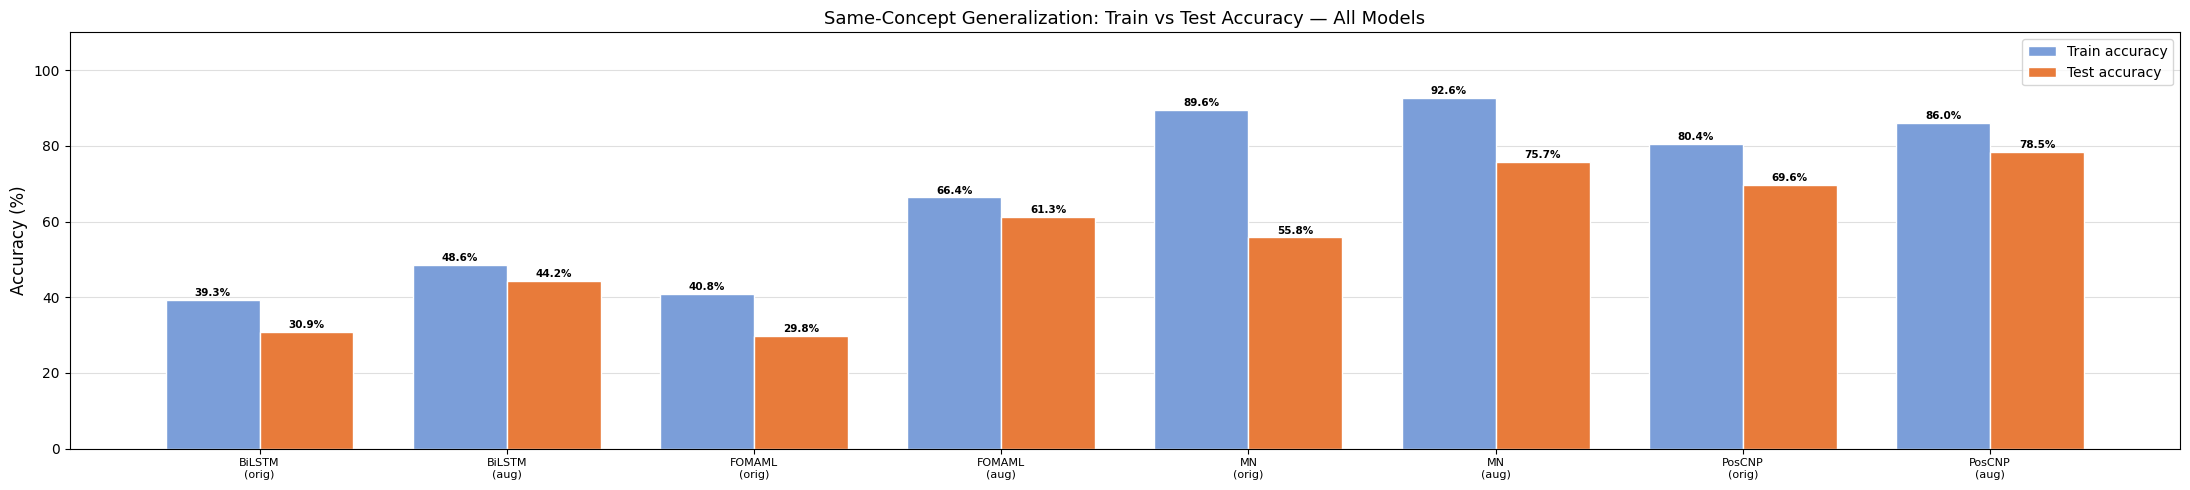


Computing per-concept accuracy for all models...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


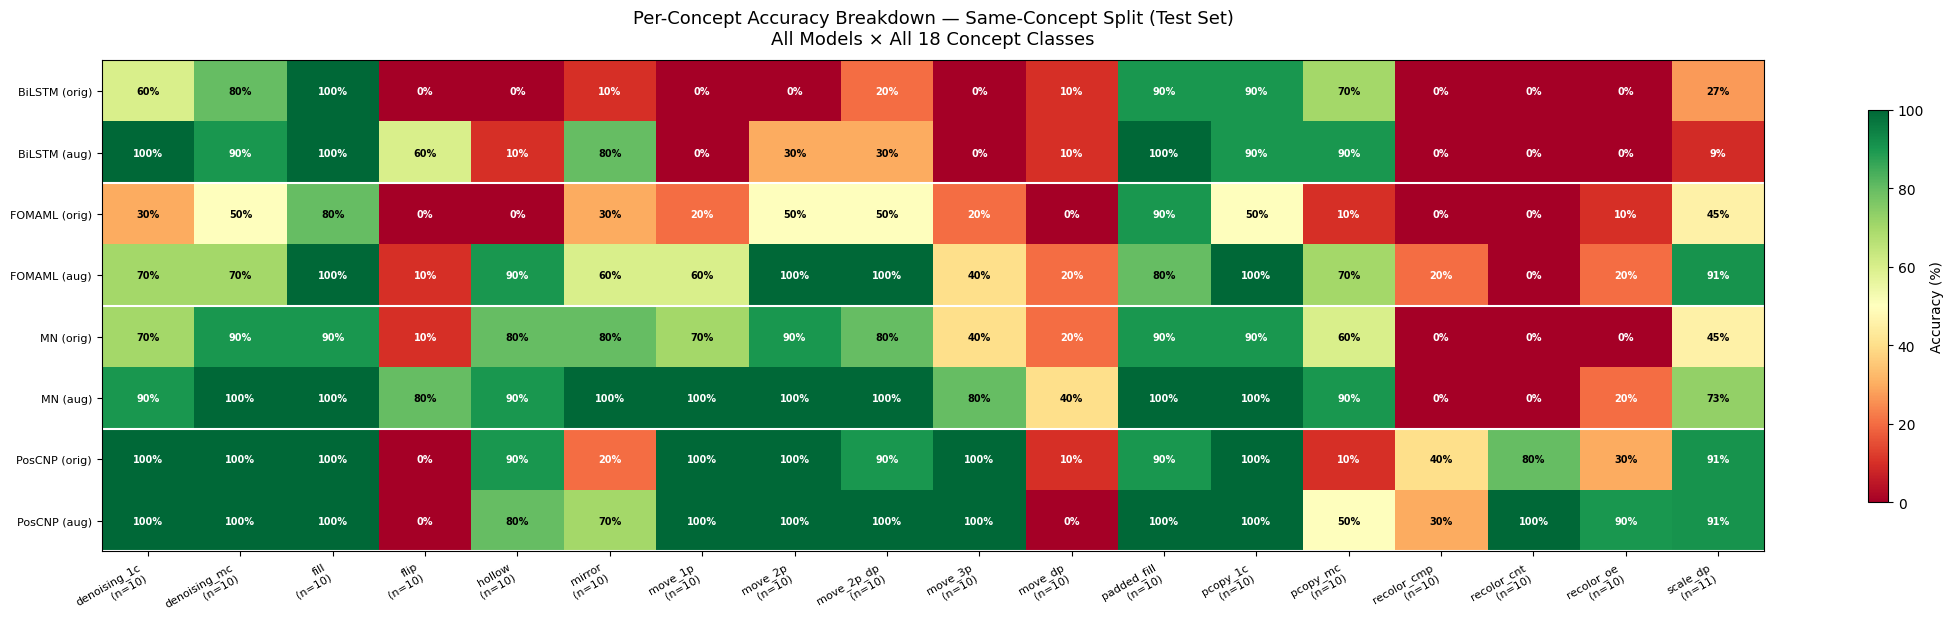

Done.


In [23]:
# ── Load Same-Concept Models from disk ───────────────────────────────────
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def _load_sc(cls, filename, **kw):
    m = cls(**kw)
    m.load_state_dict(torch.load(os.path.join(SC_LOAD_DIR, filename), map_location=_device))
    return m.to(_device).eval()

model_baseline     = _load_sc(ImprovedARCModel, "bilstm_orig.pt",  padding_idx=PADDING_VALUE)
model_baseline_aug = _load_sc(ImprovedARCModel, "bilstm_aug.pt",   padding_idx=PADDING_VALUE)
model_maml         = _load_sc(ImprovedARCModel, "fomaml_orig.pt",  padding_idx=PADDING_VALUE)
model_maml_aug     = _load_sc(ImprovedARCModel, "fomaml_aug.pt",   padding_idx=PADDING_VALUE)
model_mn           = _load_sc(MatchingNetworks, "mn_orig.pt",      padding_idx=PADDING_VALUE)
model_mn_aug       = _load_sc(MatchingNetworks, "mn_aug.pt",       padding_idx=PADDING_VALUE)

adv_sc_model       = _load_sc(PosCNP,           "poscnp_orig.pt",  padding_idx=PADDING_VALUE)
adv_sc_model_aug   = _load_sc(PosCNP,           "poscnp_aug.pt",   padding_idx=PADDING_VALUE)
print("All same-concept models loaded from disk.")

import contextlib, io
from collections import defaultdict
from matplotlib.patches import Patch
from IPython.display import display
import matplotlib.pyplot as plt

# ── Chart: Same-Concept — Model Comparison (Original vs Augmented) ───────
print("Re-evaluating all same-concept models for comparison chart...")

_sc_evals = [
    ("BiLSTM\n(orig)",        model_baseline,        evaluate_model,          0),
    ("BiLSTM\n(aug)",         model_baseline_aug,    evaluate_model,          0),
    ("FOMAML\n(orig)",        model_maml,            evaluate_model,         20),
    ("FOMAML\n(aug)",         model_maml_aug,        evaluate_model,         20),
    ("MN\n(orig)",            model_mn,              evaluate_episodic_model,  0),
    ("MN\n(aug)",             model_mn_aug,          evaluate_episodic_model,  0),

    ("PosCNP\n(orig)",        adv_sc_model,          evaluate_episodic_model,  0),
    ("PosCNP\n(aug)",         adv_sc_model_aug,      evaluate_episodic_model,  0),
]

labels, train_accs, test_accs = [], [], []
print(f"  {'Model':<22}  {'Train':>7}  {'Test':>7}")
print(f"  {'-'*22}  {'-'*7}  {'-'*7}")
for label, model, fn, adapt in _sc_evals:
    lname = label.replace(chr(10), ' ')
    with contextlib.redirect_stdout(io.StringIO()):
        tr = fn(model, meta_train_tasks, adapt_steps=adapt) if adapt > 0 else fn(model, meta_train_tasks)
        te = fn(model, meta_test_tasks,  adapt_steps=adapt) if adapt > 0 else fn(model, meta_test_tasks)
    labels.append(label)
    train_accs.append(tr * 100)
    test_accs.append(te * 100)
    print(f"  {lname:<22}  {tr*100:>6.1f}%  {te*100:>6.1f}%")

# ── Summary grouped bar chart (train vs test) ─────────────────────────────
xs = np.arange(len(labels)); w = 0.38
fig1, ax1 = plt.subplots(figsize=(22, 5))
b1 = ax1.bar(xs - w/2, train_accs, w, color='#7B9ED9', label='Train accuracy', edgecolor='white')
b2 = ax1.bar(xs + w/2, test_accs,  w, color='#E87B3A', label='Test accuracy',  edgecolor='white')
for bar, val in zip(list(b1)+list(b2), train_accs+test_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.set_xticks(xs); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Same-Concept Generalization: Train vs Test Accuracy — All Models', fontsize=13)
ax1.set_ylim(0, 110); ax1.yaxis.grid(True, alpha=0.4); ax1.set_axisbelow(True)
ax1.legend(fontsize=10)
fig1.tight_layout()
display(fig1)
plt.close(fig1)

# ── Per-concept breakdown (test set) ─────────────────────────────────────
print("\nComputing per-concept accuracy for all models...")

_concepts_sorted = sorted(set(t["concept"] for t in meta_test_tasks))

def _eval_per_concept(model, tasks, fn, adapt):
    """Returns {concept: accuracy%} with stdout suppressed."""
    groups = defaultdict(list)
    for t in tasks:
        groups[t["concept"]].append(t)
    result = {}
    for concept, subset in groups.items():
        with contextlib.redirect_stdout(io.StringIO()):
            acc = fn(model, subset, adapt_steps=adapt) if adapt > 0 else fn(model, subset)
        result[concept] = acc * 100
    return result

_heatmap_data  = []
_model_labels  = [l.replace('\n', ' ') for l, *_ in _sc_evals]
_concept_counts = {c: sum(1 for t in meta_test_tasks if t["concept"] == c)
                   for c in _concepts_sorted}

for label, model, fn, adapt in _sc_evals:
    print(f"  Computing: {label.replace(chr(10), ' '):<22}", end="\r")
    row = _eval_per_concept(model, meta_test_tasks, fn, adapt)
    _heatmap_data.append([row.get(c, 0) for c in _concepts_sorted])
print(" " * 50)

_concept_labels = [f"{c.replace('1d_', '')}\n(n={_concept_counts[c]})"
                   for c in _concepts_sorted]

# ── Heatmap ───────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(22, len(_sc_evals) * 0.55 + 2))
im = ax2.imshow(_heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)

ax2.set_xticks(range(len(_concepts_sorted)))
ax2.set_xticklabels(_concept_labels, fontsize=8, rotation=30, ha='right')
ax2.set_yticks(range(len(_model_labels)))
ax2.set_yticklabels(_model_labels, fontsize=8)

for i, row in enumerate(_heatmap_data):
    for j, val in enumerate(row):
        txt_color = 'white' if val < 25 or val > 80 else 'black'
        ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=7, fontweight='bold', color=txt_color)

for k in range(1, len(_sc_evals), 2):
    ax2.axhline(k + 0.5, color='white', linewidth=1.5)

plt.colorbar(im, ax=ax2, label='Accuracy (%)', shrink=0.8)
ax2.set_title('Per-Concept Accuracy Breakdown — Same-Concept Split (Test Set)\n'
              'All Models × All 18 Concept Classes', fontsize=13, pad=12)
fig2.tight_layout()
display(fig2)
plt.close(fig2)
print("Done.")

<div align="right"><a href="#top">↑ back to contents</a></div>

## 9. Cross-Concept Experiments

This is the harder setting: entire concept classes are withheld from training.
The model must generalise to *transformation types it has never seen*.

### Why is this hard?

Without ever seeing a "flip" transformation during training, the model cannot learn
what "flipping" means.  It must instead learn a more abstract meta-skill:
*"given 2-3 examples of a new rule, figure out the rule and apply it"*.
This is much closer to genuine in-context learning.

In [25]:
# ── CC Exp 1: BiLSTM Baseline (Standard Supervised Learning, Cross-Concept) ──
print("=" * 60)
print("CC-EXP 1: BiLSTM Baseline (standard supervised learning)")
print("=" * 60)

_cc_train_in, _cc_train_out = _collect_pairs(cc_meta_train_tasks)
_cc_test_in,  _cc_test_out  = _collect_pairs(cc_meta_test_tasks)

print(f"\nTrain pairs : {len(_cc_train_in)}  (from {len(cc_meta_train_tasks)} tasks)")
print(f"Test  pairs : {len(_cc_test_in)}   (from {len(cc_meta_test_tasks)} tasks)")
train_concepts = set(t["concept"] for t in cc_meta_train_tasks)
test_concepts  = set(t["concept"] for t in cc_meta_test_tasks)
print(f"Train concepts : {sorted(train_concepts)}")
print(f"Test  concepts : {sorted(test_concepts)}")
assert train_concepts.isdisjoint(test_concepts), "Concept leak detected!"

cc_model_baseline     = ImprovedARCModel(padding_idx=PADDING_VALUE)
cc_model_baseline_aug = ImprovedARCModel(padding_idx=PADDING_VALUE)

_t0 = time.time()

print("\n[Original cross-concept data]")
cc_model_baseline = _train_supervised(
    cc_model_baseline,
    list(range(len(_cc_train_in))), _cc_train_in, _cc_train_out,
    epochs=20, lr=1e-3)
print("Test (held-out concepts):"); _eval_supervised(
    cc_model_baseline, list(range(len(_cc_test_in))), _cc_test_in, _cc_test_out)

# Augmented: add augmented pairs to training set only; test set unchanged
_cc_aug_in, _cc_aug_out = _collect_pairs(cc_aug_meta_train_tasks)
_cc_all_in_aug   = _cc_train_in  + _cc_aug_in
_cc_all_out_aug  = _cc_train_out + _cc_aug_out
_cc_train_idx_aug = list(range(len(_cc_all_in_aug)))

print(f"\n[Augmented data — {len(_cc_train_idx_aug)} train pairs "
      f"(original + {len(_cc_aug_in)} augmented)]")
cc_model_baseline_aug = _train_supervised(
    cc_model_baseline_aug,
    _cc_train_idx_aug, _cc_all_in_aug, _cc_all_out_aug,
    epochs=20, lr=1e-3)
print("Test (held-out concepts):"); _eval_supervised(
    cc_model_baseline_aug, list(range(len(_cc_test_in))), _cc_test_in, _cc_test_out)

print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")

CC-EXP 1: BiLSTM Baseline (standard supervised learning)

Train pairs : 2804  (from 701 tasks)
Test  pairs : 800   (from 200 tasks)
Train concepts : ['1d_denoising_1c', '1d_denoising_mc', '1d_flip', '1d_mirror', '1d_move_1p', '1d_move_2p_dp', '1d_move_3p', '1d_padded_fill', '1d_pcopy_1c', '1d_pcopy_mc', '1d_recolor_cmp', '1d_recolor_cnt', '1d_recolor_oe', '1d_scale_dp']
Test  concepts : ['1d_fill', '1d_hollow', '1d_move_2p', '1d_move_dp']

[Original cross-concept data]
  Epoch 5/20 | Loss: 0.5396
  Epoch 10/20 | Loss: 0.3109
  Epoch 15/20 | Loss: 0.2589
  Epoch 20/20 | Loss: 0.2394
Test (held-out concepts):
  Test Accuracy: 223/800 = 27.88%

[Augmented data — 8412 train pairs (original + 5608 augmented)]
  Epoch 5/20 | Loss: 0.3753
  Epoch 10/20 | Loss: 0.3040
  Epoch 15/20 | Loss: 0.2606
  Epoch 20/20 | Loss: 0.2255
Test (held-out concepts):
  Test Accuracy: 206/800 = 25.75%

Training time: 0m 30s


In [30]:
# ── CC Exp 2: FOMAML ─────────────────────────────────────────────────────
print("=" * 60)
print("CC-EXP 2: BiLSTM + FOMAML (cross-concept)")
print("=" * 60)

cc_model_maml     = ImprovedARCModel(padding_idx=PADDING_VALUE)
cc_model_maml_aug = ImprovedARCModel(padding_idx=PADDING_VALUE)

if TRAIN_CC_FOMAML:
    _t0 = time.time()
    print("\n[Original]")
    cc_model_maml = train_maml_fomaml(cc_model_maml, cc_meta_train_tasks, epochs=15)
    print("Result without adaptation:"); evaluate_model(cc_model_maml, cc_meta_test_tasks, adapt_steps=0)
    print("Result with adaptation:"); evaluate_model(cc_model_maml, cc_meta_test_tasks, adapt_steps=20)

    print("\n[Augmented]")
    cc_model_maml_aug = train_maml_fomaml(
        cc_model_maml_aug, cc_meta_train_tasks + cc_aug_meta_train_tasks, epochs=15)
    print("Result without adaptation:"); evaluate_model(cc_model_maml_aug, cc_meta_test_tasks, adapt_steps=0)
    print("Result with adaptation:"); evaluate_model(cc_model_maml_aug, cc_meta_test_tasks, adapt_steps=20)
    print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")
else:
    print("  [SKIPPED — TRAIN_CC_FOMAML = False]")

CC-EXP 2: BiLSTM + FOMAML (cross-concept)

[Original]


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


  Epoch 5/15 | Meta Loss: 4.4547
  Epoch 10/15 | Meta Loss: 2.6904
  Epoch 15/15 | Meta Loss: 1.9129
Result without adaptation:
  Test Accuracy: 32/200 = 16.00%
Result with adaptation:
  Test Accuracy: 86/200 = 43.00%

[Augmented]
  Epoch 5/15 | Meta Loss: 3.3454
  Epoch 10/15 | Meta Loss: 1.9808
  Epoch 15/15 | Meta Loss: 1.5486
Result without adaptation:
  Test Accuracy: 7/200 = 3.50%
Result with adaptation:
  Test Accuracy: 77/200 = 38.50%

Training time: 16m 58s


In [ ]:
# ── ADV-EXP 3: PosCNP + MAML — Cross-Concept Split ──────────────────────
print("=" * 60)
print("ADV-EXP 2: PosCNP + MAML — Cross-Concept Split")
print("=" * 60)

adv_cc_model     = PosCNP(padding_idx=PADDING_VALUE)
adv_cc_model_aug = PosCNP(padding_idx=PADDING_VALUE)

if TRAIN_CC_POSCNP:
    _t0 = time.time()
    print("\n--- Training on original cross-concept data (MAML) ---")
    adv_cc_model = train_pos_maml(
        adv_cc_model, cc_meta_train_tasks,
        epochs=15, meta_lr=1e-3, inner_lr=1e-2, inner_steps=5, tasks_per_batch=8
    )
    print("\n[Original Data Results]")
    print("No adaptation:")
    adv_cc_acc = evaluate_pos_adapted(adv_cc_model, cc_meta_test_tasks, adapt_steps=0, adapt_lr=5e-3)
    print("With 20 adaptation steps:")
    adv_cc_acc_adapt = evaluate_pos_adapted(adv_cc_model, cc_meta_test_tasks, adapt_steps=20, adapt_lr=5e-3)

    print("\n--- Training on mixed (original + augmented) cross-concept data (MAML) ---")
    adv_cc_model_aug = train_pos_maml(
        adv_cc_model_aug, cc_meta_train_tasks + cc_aug_meta_train_tasks,
        epochs=15, meta_lr=1e-3, inner_lr=1e-2, inner_steps=5, tasks_per_batch=8
    )
    print("\n[Augmented Data Results]")
    print("No adaptation:")
    adv_cc_acc_aug = evaluate_pos_adapted(adv_cc_model_aug, cc_meta_test_tasks, adapt_steps=0, adapt_lr=5e-3)
    print("With 20 adaptation steps:")
    adv_cc_acc_adapt_aug = evaluate_pos_adapted(adv_cc_model_aug, cc_meta_test_tasks, adapt_steps=20, adapt_lr=5e-3)

    print(f"\n  PosCNP+MAML original:  {adv_cc_acc*100:.2f}% (no adapt) / {adv_cc_acc_adapt*100:.2f}% (adapted)")
    print(f"  PosCNP+MAML augmented: {adv_cc_acc_aug*100:.2f}% (no adapt) / {adv_cc_acc_adapt_aug*100:.2f}% (adapted)")
    print(f"\nTraining time: {_fmt_time(time.time() - _t0)}")
else:
    print("  [SKIPPED — TRAIN_CC_POSCNP = False]")

ADV-EXP 2: PosCNP + MAML — Cross-Concept Split

--- Training on original cross-concept data (MAML) ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


  Epoch 5/15 | Meta Loss: 2.6280
  Epoch 10/15 | Meta Loss: 1.1857
  Epoch 15/15 | Meta Loss: 0.7053

[Original Data Results]
No adaptation:
  Test Accuracy: 69/200 = 34.50%
With 20 adaptation steps:
  Test Accuracy: 101/200 = 50.50%

--- Training on mixed (original + augmented) cross-concept data (MAML) ---
  Epoch 5/15 | Meta Loss: 2.0376
  Epoch 10/15 | Meta Loss: 0.5131
  Epoch 15/15 | Meta Loss: 0.2246

[Augmented Data Results]
No adaptation:
  Test Accuracy: 108/200 = 54.00%
With 20 adaptation steps:
  Test Accuracy: 121/200 = 60.50%

  PosCNP+MAML original:  34.50% (no adapt) / 50.50% (adapted)
  PosCNP+MAML augmented: 54.00% (no adapt) / 60.50% (adapted)

Training time: 44m 29s


In [36]:
# ── Save Cross-Concept Models ────────────────────────────────────────────
import os, zipfile

_cc_to_save = [
    ("bilstm_orig",      cc_model_baseline),
    ("bilstm_aug",       cc_model_baseline_aug),
    ("fomaml_orig",      cc_model_maml),
    ("fomaml_aug",       cc_model_maml_aug),
    ("poscnp_orig",      adv_cc_model),
    ("poscnp_aug",       adv_cc_model_aug),
]
for _name, _model in _cc_to_save:
    _path = os.path.join(CC_SAVE_DIR, f"{_name}.pt")
    torch.save(_model.state_dict(), _path)
    print(f"  Saved → {_path}")

_cc_zip_path = "/kaggle/working/cc_models.zip"
with zipfile.ZipFile(_cc_zip_path, "w", zipfile.ZIP_DEFLATED) as _zf:
    for _name, _ in _cc_to_save:
        _pt = os.path.join(CC_SAVE_DIR, f"{_name}.pt")
        _zf.write(_pt, arcname=f"cc/{_name}.pt")
print(f"\nZipped → {_cc_zip_path}")

  Saved → /kaggle/working/saved_models/cc/bilstm_orig.pt
  Saved → /kaggle/working/saved_models/cc/bilstm_aug.pt
  Saved → /kaggle/working/saved_models/cc/fomaml_orig.pt
  Saved → /kaggle/working/saved_models/cc/fomaml_aug.pt
  Saved → /kaggle/working/saved_models/cc/poscnp_orig.pt
  Saved → /kaggle/working/saved_models/cc/poscnp_aug.pt

Zipped → /kaggle/working/cc_models.zip


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.15 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


All cross-concept models loaded from disk.
Re-evaluating all cross-concept models for comparison chart...
  Model                     Train     Test
  ----------------------  -------  -------
  BiLSTM (orig)             44.4%    28.0%
  BiLSTM (aug)              58.8%    24.5%


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


  FOMAML (orig)             49.4%    43.0%
  FOMAML (aug)              63.1%    38.5%
  PosCNP+MAML (orig)        67.8%    48.0%
  PosCNP+MAML (aug)         87.2%    61.0%


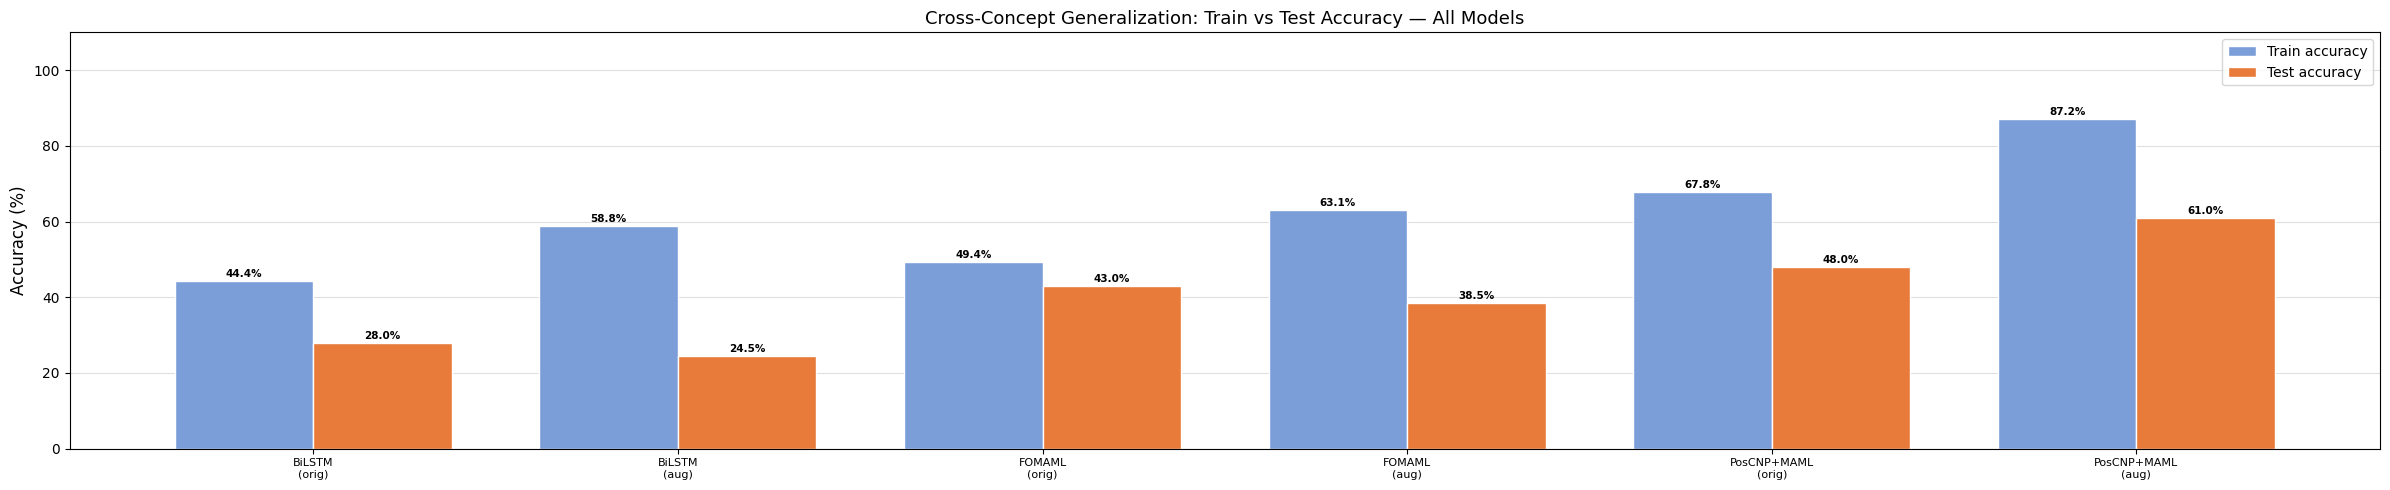


Computing per-concept accuracy for all cross-concept models...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


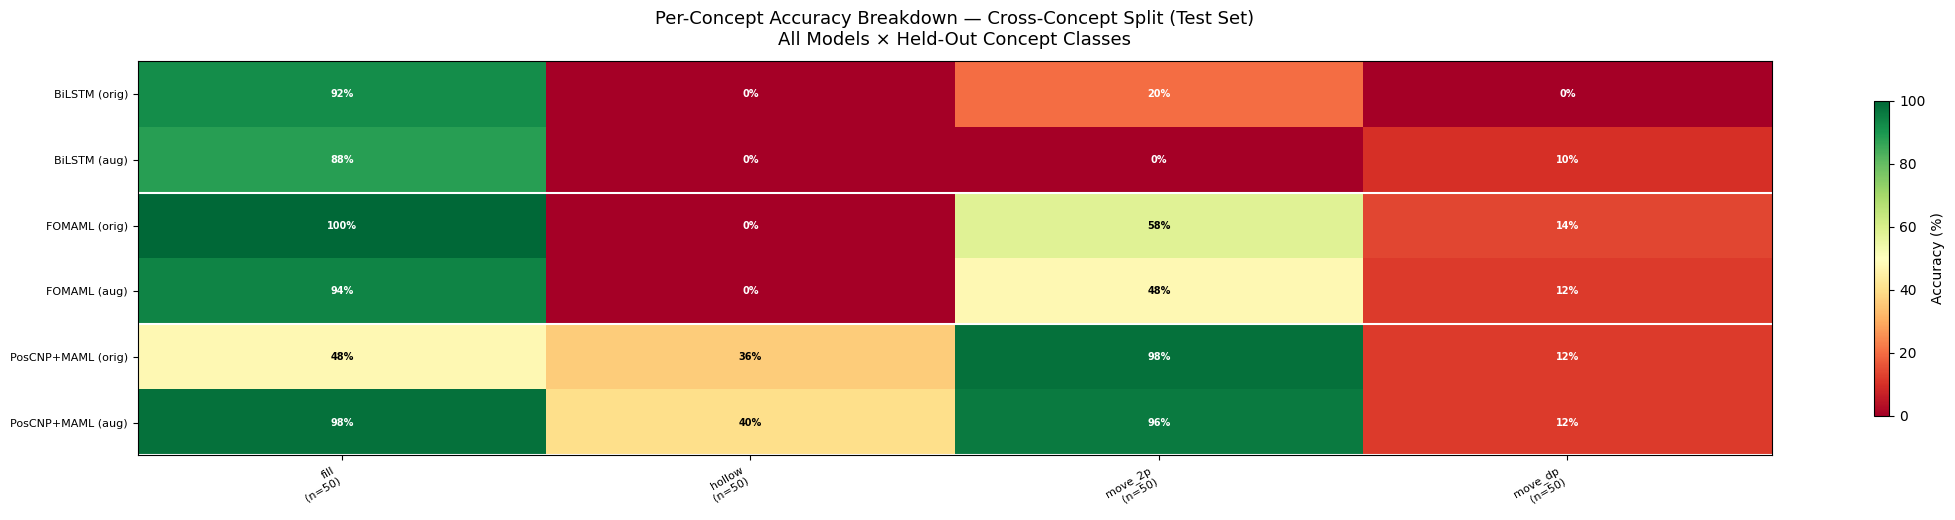

Done.


In [38]:
# ── Load Cross-Concept Models from disk ──────────────────────────────────
_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def _load_cc(cls, filename, **kw):
    m = cls(**kw)
    m.load_state_dict(torch.load(os.path.join(CC_LOAD_DIR, filename), map_location=_device))
    return m.to(_device).eval()

cc_model_baseline     = _load_cc(ImprovedARCModel, "bilstm_orig.pt",   padding_idx=PADDING_VALUE)
cc_model_baseline_aug = _load_cc(ImprovedARCModel, "bilstm_aug.pt",    padding_idx=PADDING_VALUE)
cc_model_maml         = _load_cc(ImprovedARCModel, "fomaml_orig.pt",   padding_idx=PADDING_VALUE)
cc_model_maml_aug     = _load_cc(ImprovedARCModel, "fomaml_aug.pt",    padding_idx=PADDING_VALUE)
adv_cc_model          = _load_cc(PosCNP,           "poscnp_orig.pt",   padding_idx=PADDING_VALUE)
adv_cc_model_aug      = _load_cc(PosCNP,           "poscnp_aug.pt",    padding_idx=PADDING_VALUE)
print("All cross-concept models loaded from disk.")

import contextlib, io
from collections import defaultdict
from matplotlib.patches import Patch
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np

# ── Chart: Cross-Concept — Model Comparison (Original vs Augmented) ──────
print("Re-evaluating all cross-concept models for comparison chart...")

_cc_compare_evals = [
    ("BiLSTM\n(orig)",          cc_model_baseline,        evaluate_model,          0),
    ("BiLSTM\n(aug)",           cc_model_baseline_aug,    evaluate_model,          0),
    ("FOMAML\n(orig)",          cc_model_maml,            evaluate_model,         20),
    ("FOMAML\n(aug)",           cc_model_maml_aug,        evaluate_model,         20),
    ("PosCNP+MAML\n(orig)",     adv_cc_model,             evaluate_pos_adapted,  20),
    ("PosCNP+MAML\n(aug)",      adv_cc_model_aug,         evaluate_pos_adapted,  20),
]

labels, train_accs, test_accs = [], [], []
print(f"  {'Model':<22}  {'Train':>7}  {'Test':>7}")
print(f"  {'-'*22}  {'-'*7}  {'-'*7}")
for label, model, fn, adapt in _cc_compare_evals:
    lname = label.replace(chr(10), ' ')
    with contextlib.redirect_stdout(io.StringIO()):
        tr = fn(model, cc_meta_train_tasks, adapt_steps=adapt) if adapt > 0 else fn(model, cc_meta_train_tasks)
        te = fn(model, cc_meta_test_tasks,  adapt_steps=adapt) if adapt > 0 else fn(model, cc_meta_test_tasks)
    labels.append(label)
    train_accs.append(tr * 100)
    test_accs.append(te * 100)
    print(f"  {lname:<22}  {tr*100:>6.1f}%  {te*100:>6.1f}%")

# ── Summary grouped bar chart (train vs test) ─────────────────────────────
xs = np.arange(len(labels)); w = 0.38
fig1, ax1 = plt.subplots(figsize=(24, 5))
b1 = ax1.bar(xs - w/2, train_accs, w, color='#7B9ED9', label='Train accuracy', edgecolor='white')
b2 = ax1.bar(xs + w/2, test_accs,  w, color='#E87B3A', label='Test accuracy',  edgecolor='white')
for bar, val in zip(list(b1)+list(b2), train_accs+test_accs):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
ax1.set_xticks(xs); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Cross-Concept Generalization: Train vs Test Accuracy — All Models', fontsize=13)
ax1.set_ylim(0, 110); ax1.yaxis.grid(True, alpha=0.4); ax1.set_axisbelow(True)
ax1.legend(fontsize=10)
fig1.tight_layout()
display(fig1)
plt.close(fig1)

# ── Per-concept breakdown (test set) ─────────────────────────────────────
print("\nComputing per-concept accuracy for all cross-concept models...")

_cc_concepts_sorted = sorted(set(t["concept"] for t in cc_meta_test_tasks))
_cc_concept_counts  = {c: sum(1 for t in cc_meta_test_tasks if t["concept"] == c)
                       for c in _cc_concepts_sorted}
_cc_compare_model_labels = [l.replace('\n', ' ') for l, *_ in _cc_compare_evals]
_cc_compare_heatmap      = []

for label, model, fn, adapt in _cc_compare_evals:
    print(f"  Computing: {label.replace(chr(10), ' '):<22}", end="\r")
    groups = defaultdict(list)
    for t in cc_meta_test_tasks:
        groups[t["concept"]].append(t)
    row = {}
    for concept, subset in groups.items():
        with contextlib.redirect_stdout(io.StringIO()):
            acc = fn(model, subset, adapt_steps=adapt) if adapt > 0 else fn(model, subset)
        row[concept] = acc * 100
    _cc_compare_heatmap.append([row.get(c, 0) for c in _cc_concepts_sorted])
print(" " * 50)

_cc_compare_concept_labels = [f"{c.replace('1d_', '')}\n(n={_cc_concept_counts[c]})"
                               for c in _cc_concepts_sorted]

fig2, ax2 = plt.subplots(figsize=(22, len(_cc_compare_evals) * 0.55 + 2))
im = ax2.imshow(_cc_compare_heatmap, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax2.set_xticks(range(len(_cc_concepts_sorted)))
ax2.set_xticklabels(_cc_compare_concept_labels, fontsize=8, rotation=30, ha='right')
ax2.set_yticks(range(len(_cc_compare_model_labels)))
ax2.set_yticklabels(_cc_compare_model_labels, fontsize=8)
for i, row_vals in enumerate(_cc_compare_heatmap):
    for j, val in enumerate(row_vals):
        txt_color = 'white' if val < 25 or val > 80 else 'black'
        ax2.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=7, fontweight='bold', color=txt_color)
for k in range(1, len(_cc_compare_evals), 2):
    ax2.axhline(k + 0.5, color='white', linewidth=1.5)
plt.colorbar(im, ax=ax2, label='Accuracy (%)', shrink=0.8)
ax2.set_title('Per-Concept Accuracy Breakdown — Cross-Concept Split (Test Set)\n'
              'All Models × Held-Out Concept Classes', fontsize=13, pad=12)
fig2.tight_layout()
display(fig2)
plt.close(fig2)
print("Done.")

<div align="right"><a href="#top">↑ back to contents</a></div>

## 10. Evaluation Robustness: Cross-Concept Split Analysis

### The Evaluation Problem

For cross-concept evaluation, the score depends on *which* concepts are held out.
If the test concepts happen to be easier than average, the model looks better than it is.

We investigate this in two ways:
1. **Per-concept accuracy** across all 18 concepts — to see if the original split was biased
2. **Leave-One-Concept-Out (LOCO)** — the gold standard: hold each concept out once,
   average across all 18 rounds, with no split bias possible

**Note:** These cells evaluate the saved `adv_cc_model` (PosCNP + MAML, best cross-concept model).
Loaded from `saved_models/cc/poscnp_orig.pt` before running.

In [39]:
# ── Random-Split Averaging — PosCNP + MAML ───────────────────────────────
import numpy as np, contextlib, io as _io, random as _rs, time as _rst
from collections import defaultdict

concept_tasks = defaultdict(list)
for t in tasks:
    concept_tasks[t["concept"]].append(t)
all_concepts_list = sorted(concept_tasks.keys())

orig_test_concepts = sorted(set(t["concept"] for t in cc_meta_test_tasks))
n_held = len(orig_test_concepts)   # keep same split size as group-based split

_RS_ROUNDS = 5     # number of random splits
_RS_EPOCHS = 5     # epochs per round (abbreviated; full training = 15)
_rs.seed(42)

print("=" * 65)
print(f"RANDOM-SPLIT AVERAGING — PosCNP + MAML  ({_RS_ROUNDS} rounds, {n_held} held-out concepts each)")
print(f"Each round: train fresh PosCNP+MAML on {len(all_concepts_list) - n_held} concepts ({_RS_EPOCHS} epochs),")
print(f"            then evaluate with 20 adapt steps on the held-out concepts.")
print("=" * 65)

round_accs = []

for rnd in range(_RS_ROUNDS):
    held_concepts  = sorted(_rs.sample(all_concepts_list, n_held))
    train_concepts = [c for c in all_concepts_list if c not in held_concepts]
    rnd_train      = [t for t in tasks if t["concept"] in train_concepts]
    rnd_test       = [t for c in held_concepts for t in concept_tasks[c]]

    print(f"\n[Round {rnd+1}/{_RS_ROUNDS}]")
    print(f"  Held-out : {', '.join(held_concepts)}")
    print(f"  Training on {len(rnd_train)} tasks ... ", end="", flush=True)
    _t0 = _rst.time()

    _rs_model = PosCNP(padding_idx=PADDING_VALUE)
    with contextlib.redirect_stdout(_io.StringIO()):
        _rs_model = train_pos_maml(
            _rs_model, rnd_train,
            epochs=_RS_EPOCHS, meta_lr=1e-3, inner_lr=1e-2,
            inner_steps=5, tasks_per_batch=8)

    acc = evaluate_pos_adapted(_rs_model, rnd_test, adapt_steps=20, adapt_lr=5e-3)
    round_accs.append(acc * 100)
    print(f"{acc*100:.1f}%  ({_fmt_time(_rst.time()-_t0)})")

print(f"\n{'─'*65}")
print(f"  Random-split mean ± std : {np.mean(round_accs):.1f}% ± {np.std(round_accs):.1f}%")
print(f"  Individual rounds       : {[f'{a:.1f}%' for a in round_accs]}")
print(f"  ({_RS_EPOCHS} epochs/round — abbreviated. Full training = 15 epochs.")

RANDOM-SPLIT AVERAGING — PosCNP + MAML  (5 rounds, 4 held-out concepts each)
Each round: train fresh PosCNP+MAML on 14 concepts (5 epochs),
            then evaluate with 20 adapt steps on the held-out concepts.

[Round 1/5]
  Held-out : 1d_denoising_1c, 1d_flip, 1d_move_2p_dp, 1d_scale_dp
  Training on 700 tasks ... 

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.15 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1141: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1480.)
  result = _VF.lstm(


  Test Accuracy: 66/201 = 32.84%
32.8%  (4m 18s)

[Round 2/5]
  Held-out : 1d_denoising_1c, 1d_fill, 1d_move_3p, 1d_recolor_oe
  Training on 701 tasks ...   Test Accuracy: 34/200 = 17.00%
17.0%  (4m 19s)

[Round 3/5]
  Held-out : 1d_hollow, 1d_move_2p_dp, 1d_move_3p, 1d_padded_fill
  Training on 701 tasks ...   Test Accuracy: 31/200 = 15.50%
15.5%  (4m 18s)

[Round 4/5]
  Held-out : 1d_denoising_1c, 1d_denoising_mc, 1d_recolor_cmp, 1d_recolor_cnt
  Training on 701 tasks ...   Test Accuracy: 16/200 = 8.00%
8.0%  (4m 17s)

[Round 5/5]
  Held-out : 1d_mirror, 1d_padded_fill, 1d_pcopy_1c, 1d_recolor_cmp
  Training on 701 tasks ...   Test Accuracy: 6/200 = 3.00%
3.0%  (4m 16s)

─────────────────────────────────────────────────────────────────
  Random-split mean ± std : 15.3% ± 10.1%
  Individual rounds       : ['32.8%', '17.0%', '15.5%', '8.0%', '3.0%']
  (5 epochs/round — abbreviated. Full training = 15 epochs.
